# Architecture 5K test — do mixed signals beat measurement-only?

**Question.** Does labeling *non-decisive* rows with the combiner (`max(l1,l2) + α·llm_a + β·r1`) and
adding them to the router's training set improve routing over measurement alone?

**Method (the non-circular reframe).**
- **train** = OG decisive rows **+** projected non-decisive rows (combiner scores → normalized [0,1] triple)
- **test** = held-out **OG decisive** rows only — real qrels-grounded scores the combiner never touched
- **baseline** = train on OG decisive only

A gain is real generalization, not imitation, because the test truth is independent of the combiner.

**Target: v2-100K** (`rungs/100k-v2/labeling/labels.parquet`, 91,093 labelled rows).

**Cover (stratified, re-derived from v2-100K's own supply — spans identifier density × regime × domain):**
`crumb-legal-qa` (0.000, legal, indexed/free) · `scirgen-geo-en` (0.015, science) ·
`quest` (0.035, general, all_tied) · `clerc` (0.085, legal-long) · `finder` (0.140, finance) ·
`rarb-math` (0.161, math). Code + medical dropped — v2-100K has no affordable supply (code corpora
100K+ docs → $7.50–9 to index; clinical-trial collapsed to 121 non-decisive rows).

**Caveats (honest boundaries).** English-only — the v3 labels carry *zero* non-English non-decisive
supply, so this validates an English-corpus architecture only. l2 (gemini) doc-indexing is ~$0.25–$7.50
per lane; r1/llm_a per-row spend dominates. Everything paid is `RUN_LIVE`-gated and cached to disk, so
re-runs and Run-All never re-spend.

In [33]:
import sys, pathlib
SRC = pathlib.Path.cwd()
SRC = SRC if (SRC / "scripts").exists() else SRC / "src"
sys.path.insert(0, str(SRC))

# Reload the mutable pipeline modules so edits to their .py land on a §1 re-run
# instead of a kernel restart. Order = leaf -> dependent (indexer before the
# modules that import from it). Add a module here if you start editing it.
import importlib
import hybrid_search_rrf_dataset.indexer as _idx_mod
import hybrid_search_rrf_dataset.fusion as _fus_mod
import scripts.r1_rerank as _r1_mod
import scripts.final_combiner as _fc_mod
for _m in (_idx_mod, _fus_mod, _r1_mod, _fc_mod):
    importlib.reload(_m)

import json, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from qdrant_client import QdrantClient

from composition.pool_v3 import SCORES, TOL
from hybrid_search_rrf_dataset.fusion import DenseOnlyStrategy, PureRRFStrategy, SparseOnlyStrategy
from hybrid_search_rrf_dataset.objective import RouterObjective
from hybrid_search_rrf_dataset.indexer import CorpusIndexer, CorpusDocument, EmbeddingCache
from hybrid_search_rrf_dataset.retrieval import SnapshotDataset
from hybrid_search_rrf_dataset.router import (
    DATA_DIR, Representation, QueryEncoder, StrategyRouter, decisive_rows, _six_column, _margin,
)
from scripts.legb import LEGB_DIR, LegBPilot, SPARSE_CFG, gemini_dense_cfg
from scripts.label_routes import _source_name
from scripts.r1_rerank import rerank, r1_route_scores
from scripts.llm_a_judge import judge_row
from scripts.final_combiner import ROUTES, project_to_router_frame, gemini_l2_cost, combine

load_dotenv()
client = QdrantClient(url=os.environ["QDRANT_CLOUD_URL"], api_key=os.environ["QDRANT_CLOUD_API_KEY"],
                      timeout=120, cloud_inference=True)
pd.set_option("display.width", 180)

ALPHA, BETA = 0.1, 0.8
# Target = v2-100K rung (rungs/100k-v2). Cover re-derived from ITS supply (v3's cover had
# two lanes the v2 selection collapsed): spans id-density 0.00->0.16 x regime x domain.
V2_LABELS = DATA_DIR / "rungs" / "100k-v2" / "labeling" / "labels.parquet"
COVER = ["crumb-legal-qa", "scirgen-geo-en", "quest", "clerc", "finder", "rarb-math"]
PER_CELL_CAP = 300          # max rows per (lane x regime) — keeps the sparse end from being swamped
JUDGE_TO_ROUTE = {"dense": "dense_only", "sparse": "sparse_only", "rrf": "pure_rrf"}

OUT = LEGB_DIR / "arch5k"; OUT.mkdir(parents=True, exist_ok=True)
DRAW_PATH = OUT / "draw.parquet"
ROWS_PATH = OUT / "rows.json"
COST_PATH = OUT / "cost.json"
pilot = LegBPilot(client, gemini_dense_cfg())   # only used for its per-lane collection names
print("cover:", COVER, "| alpha", ALPHA, "beta", BETA)

cover: ['crumb-legal-qa', 'scirgen-geo-en', 'quest', 'clerc', 'finder', 'rarb-math'] | alpha 0.1 beta 0.8


## 1. Stratified draw (free, deterministic)

Non-decisive rows only, stratified by (lane × regime) so every lane *and* every regime (`all_zero` / `all_tied` / `low_margin`) gets enough observations. Proportional sampling would let scirgen+quest swamp the sparse-end lanes. `random_state=0` so a rerun draws the same rows.

In [34]:
import pyarrow.parquet as pq

v2 = pd.read_parquet(V2_LABELS)   # the target: v2-100K rung, fully labelled (91,093 rows)
labels = v2[v2["dataset"].isin(COVER)].reset_index(drop=True)


def _empty_gold_qids(lane):
    """query_ids whose every RELEVANT gold doc has empty content — unretrievable, so
    forced all_zero for a data-quality reason, not a routing one. The v2 plan admitted
    these before the catalog.py coverage fix (id-level, not content-level); exclude them
    so they can't pollute the draw. Becomes a no-op once the plan is regenerated."""
    cp, qp = DATA_DIR / lane / "corpus.parquet", DATA_DIR / lane / "qrels.parquet"
    if not cp.exists() or not qp.exists():
        return set()
    cols = ["doc_id", "text"] + (["title"] if "title" in pq.read_schema(cp).names else [])
    c = pd.read_parquet(cp, columns=cols)
    t = c["text"].fillna("")
    if "title" in c.columns:
        t = c["title"].fillna("") + " " + t
    empt = set(c.loc[t.str.strip() == "", "doc_id"].astype(str))
    if not empt:
        return set()
    q = pd.read_parquet(qp, columns=["query_id", "doc_id", "relevance"]).astype({"query_id": str, "doc_id": str})
    gold = q[q["relevance"] >= 1].groupby("query_id")["doc_id"].agg(set)
    return {qid for qid, ds in gold.items() if ds <= empt}

bad = set().union(*(_empty_gold_qids(ln) for ln in COVER))
before = len(labels)
labels = labels[~labels["query_id"].astype(str).isin(bad)].reset_index(drop=True)
print(f"excluded {before - len(labels)} empty-gold rows (unretrievable gold; catalog.py fix stops future ones)")

mx, mn = labels[SCORES].max(axis=1), labels[SCORES].min(axis=1)
srt = np.sort(labels[SCORES].to_numpy(), axis=1)
labels["margin"] = srt[:, -1] - srt[:, -2]
labels["bucket"] = np.where(mx <= TOL, "all_zero",
                    np.where(mx - mn <= TOL, "all_tied", "decisive"))
labels["regime"] = np.where(labels["bucket"] != "decisive", labels["bucket"],
                    np.where(labels["margin"] < 0.1, "low_margin", "decisive_strong"))

non_dec = labels[labels["regime"].isin(["all_zero", "all_tied", "low_margin"])]
parts = [g.sample(min(len(g), PER_CELL_CAP), random_state=0)
         for _, g in non_dec.groupby(["dataset", "regime"])]
draw = pd.concat(parts, ignore_index=True)
draw.to_parquet(DRAW_PATH, index=False)

print(f"drew {len(draw)} rows -> {DRAW_PATH.name}")
print(pd.crosstab(draw["dataset"], draw["regime"]).to_string())

excluded 34 empty-gold rows (unretrievable gold; catalog.py fix stops future ones)
drew 5045 rows -> draw.parquet
regime          all_tied  all_zero  low_margin
dataset                                       
clerc                300        20         300
crumb-legal-qa       225       300         300
finder               300       300         300
quest                300       300         300
rarb-math            300       300         300
scirgen-geo-en       300       300         300


## 2. Index cover lanes with gemini (l2) — PAID, gated, cache-guarded

Each lane's corpus is embedded once with gemini into its own collection. `crumb-legal-qa` is already indexed (bakeoff). Skips any collection that already holds its full corpus, so Run-All never re-indexes.

In [ ]:
RUN_LIVE = False   # flip to spend: index the cover lanes with gemini

live = {c.name for c in client.get_collections().collections}
plan = pd.DataFrame([{"lane": ln, "collection": pilot.collection(ln),
                      "indexed": pilot.collection(ln) in live} for ln in COVER])
print(plan.to_string(index=False))

if RUN_LIVE:
    for ln in COVER:
        coll = pilot.collection(ln)
        corpus = SnapshotDataset(_source_name(ln), path=str(DATA_DIR)).corpus()
        indexer = CorpusIndexer(client, coll, embeddings=[gemini_dense_cfg(), SPARSE_CFG],
                                cache=EmbeddingCache(namespace=_source_name(ln)))
        indexer.ensure_collection()
        if client.count(coll, exact=True).count < len(corpus):
            docs = [CorpusDocument(**r) for r in corpus.to_dict("records")]
            fresh = indexer.missing(docs)
            print(f"[{ln}] indexing {len(fresh):,}/{len(docs):,} -> {coll}")
            # parallel=8: gemini embeds server-side per upsert, so 8 concurrent upserts
            # give ~8x throughput on this I/O-bound step (sequential was ~8s/batch). One
            # clean progress bar; sparse embeds once in bulk (no per-batch flood).
            indexer.upload(fresh, batch_size=64, parallel=8)
        else:
            print(f"[{ln}] already indexed ({coll})")
else:
    print("\nRUN_LIVE is False — no indexing. Flip it above to spend.")

## 3. Label the draw (l1 / l2 / r1 / llm_a) — PAID, gated, cache-guarded

Per row: `l1` from the stored v3 scores, `l2` from live gemini retrieval on the lane's collection, `r1` from one rerank over the routes' union, `llm_a` from the two-call judge. Persists rows **and** cost to disk. **Resumable + crash-safe**: checkpoints every 50 rows, skips already-labelled query_ids on a re-run, and a circuit breaker stops on a dead key/quota (work saved). Live progress bar shows running r1/llm_a cost + error/parse-fail counts; each saved row carries provenance (`n_judged`, `n_union`, `llm_route`) so a label is auditable after the fact.

In [ ]:
RUN_LIVE = False            # flip to spend: label the drawn rows
WORKERS = 4                 # concurrent rows; 4 not 8 — quest's ~89-doc reranks disconnect the endpoint at 8
CHECKPOINT_EVERY = 50       # persist rows+cost every N completions so a crash never loses paid work
MAX_CONSECUTIVE_ERRORS = 8  # circuit breaker: stop if the key/endpoint is clearly dead

import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from qdrant_client.http.exceptions import ResponseHandlingException
# transient connection drops (server disconnect / timeout) — retry the row, don't lose it.
# rerank()'s own retry only covers HTTP status codes (429/5xx), not a dropped connection.
_TRANSIENT = (ResponseHandlingException, requests.exceptions.RequestException)


def _checkpoint(rows, cost):
    cost["l2"] = gemini_l2_cost(rows)
    ROWS_PATH.write_text(json.dumps(rows)); COST_PATH.write_text(json.dumps(cost))


# Resume, don't blindly skip: load prior progress and label only what's left.
rows = json.loads(ROWS_PATH.read_text()) if ROWS_PATH.exists() else []
cost = json.loads(COST_PATH.read_text()) if COST_PATH.exists() else {"r1": 0.0, "llm_a": 0.0, "l2": 0.0}
done_ids = {r["query_id"] for r in rows}
todo = draw[~draw["query_id"].astype(str).isin(done_ids)].reset_index(drop=True)

if not RUN_LIVE:
    print("RUN_LIVE is False — no labeling. Flip it above to spend.")
elif todo.empty:
    print(f"complete: all {len(rows)} rows already labelled in {ROWS_PATH.name} (delete to force fresh)")
else:
    # GOLD comes from the rung manifest (candidate_manifests) — the exact gold l1 was scored
    # against. Base <lane>/qrels.parquet only covers NATURAL queries; synthetic/augmented gold
    # lives in the manifest, so reading qrels silently gave synthetic rows no gold (n_judged=0)
    # and skipped l2/r1/llm. The manifest resolves gold for every provenance uniformly.
    _man = pd.read_parquet(DATA_DIR / "rungs" / "100k-v2" / "candidate_manifests.parquet").astype({"query_id": str, "doc_id": str})
    GOLD = {k: g["doc_id"].tolist() for k, g in _man[_man["relevance"] >= 1].groupby(["dataset", "query_id"])}
    STATS = pd.read_parquet(DATA_DIR / "route_labels" / "query_corpus_stats.parquet").astype({"query_id": str}).set_index("query_id")
    lane_cache = {}
    for lane in sorted(todo["dataset"].astype(str).unique()):
        corpus = pd.read_parquet(DATA_DIR / lane / "corpus.parquet"); corpus["doc_id"] = corpus["doc_id"].astype(str)
        coll = pilot.collection(lane)
        strat = {rt: cls(client, coll, gemini_dense_cfg(), SPARSE_CFG)
                 for rt, cls in (("dense_only", DenseOnlyStrategy), ("sparse_only", SparseOnlyStrategy), ("pure_rrf", PureRRFStrategy))}
        lane_cache[lane] = (corpus, strat)

    def _label_one(d):
        """Retry transient connection drops per row (up to 3x) before giving up."""
        for attempt in range(3):
            try:
                return _label_once(d)
            except _TRANSIENT:
                if attempt == 2:
                    raise
                time.sleep(1.5 * (attempt + 1))

    def _label_once(d):
        """All paid work for ONE row; returns a result dict (no shared-state mutation)."""
        qid, query, lane = str(d.query_id), str(d.query), str(d.dataset)
        corpus, strat = lane_cache[lane]
        judged = GOLD.get((lane, qid), [])          # manifest gold — same source l1 used
        gold = corpus[corpus["doc_id"].isin(judged)]
        qstats = STATS.loc[qid] if qid in STATS.index else None
        obj = RouterObjective(min_relevance=1)
        gold_map = {doc: 1 for doc in judged}
        l1 = {rt: float(getattr(d, f"score_{rt}")) for rt in ROUTES}
        rankings, l2 = {}, {}
        for rt in ROUTES:
            rk = strat[rt].rank(query); rankings[rt] = rk
            l2[rt] = obj.assess(rk, gold_map)[0] if judged else 0.0
        r1v, n_union, r1_cost = {rt: 0.0 for rt in ROUTES}, 0, 0.0
        if judged:
            ranked = {rt: [str(x.doc_id) if hasattr(x, "doc_id") else str(x) for x in rk] for rt, rk in rankings.items()}
            union = sorted(set().union(*ranked.values()) | set(judged))
            n_union = len(union)
            udocs = corpus[corpus["doc_id"].isin(union)]
            has_t = "title" in udocs.columns
            txt = {str(r.doc_id): (f"{r.title}\\n{r.text}" if has_t else str(r.text)).strip() for r in udocs.itertuples()}
            sc, usage = rerank(query, [txt.get(x, "") for x in union])
            r1_cost = float(usage.get("cost", 0.0))
            r1v = r1_route_scores(dict(zip(union, sc)), judged, ranked, 1)
        # llm needs the gold TEXT (from manifest gold docs), NOT qrels — stats are an optional hint.
        llm_v, llm_route, llm_cost = {rt: 0.0 for rt in ROUTES}, None, 0.0
        if judged and not gold.empty:
            g0 = gold.iloc[0]
            gt = (f"{g0['title']}\\n{g0['text']}" if "title" in gold.columns and pd.notna(g0["title"]) else str(g0["text"])).strip()
            sl = ", ".join(f"{c}={qstats[c]:.3g}" for c in ("avg_idf", "max_idf", "oov_share", "vocab_overlap", "mean_pmi", "collection_size") if c in qstats.index) if qstats is not None else ""
            jlog = judge_row(query, gt[:1200], sl)
            llm_cost = float(jlog.call_a_usage.get("cost", 0.0)) + float(jlog.call_b_usage.get("cost", 0.0))
            llm_route = jlog.route
            rid = JUDGE_TO_ROUTE.get(llm_route)
            if rid is not None: llm_v[rid] = 1.0
        row = {"query_id": qid, "dataset": lane, "bucket": d.regime, "query": query,
               "l1": l1, "l2": l2, "r1": r1v, "llm_a": llm_v,
               "n_judged": len(judged), "n_union": n_union, "llm_route": llm_route}
        return {"row": row, "r1_cost": r1_cost, "llm_cost": llm_cost, "judged": bool(judged), "route": llm_route}

    print(f"labeling {len(todo)} rows x {WORKERS} workers ({len(done_ids)} done, resuming) | "
          f"prior cost r1 ${cost['r1']:.2f} llm_a ${cost['llm_a']:.2f}")
    tally = {"judged": 0, "no_judged": 0, "llm_routed": 0, "rrf": 0, "parse_fail": 0, "errors": 0}
    consec_err = 0
    prog = tqdm(total=len(todo), desc="label")
    with ThreadPoolExecutor(max_workers=WORKERS) as pool:
        futs = {pool.submit(_label_one, d): str(d.query_id) for d in todo.itertuples(index=False)}
        for n, fut in enumerate(as_completed(futs), 1):
            try:
                res = fut.result()
                rows.append(res["row"])
                cost["r1"] += res["r1_cost"]; cost["llm_a"] += res["llm_cost"]
                tally["judged" if res["judged"] else "no_judged"] += 1
                rt = res["route"]
                tally["llm_routed"] += int(rt in ("dense", "sparse", "rrf"))
                tally["rrf"] += int(rt == "rrf"); tally["parse_fail"] += int(rt == "parse_failure")
                consec_err = 0
            except Exception as exc:
                tally["errors"] += 1; consec_err += 1
                tqdm.write(f"[{futs[fut]}] FAILED ({consec_err} in a row): {type(exc).__name__}: {exc}")
                if consec_err >= MAX_CONSECUTIVE_ERRORS:
                    _checkpoint(rows, cost)
                    print(f"\\nABORT: {consec_err} consecutive failures (dead key / quota / endpoint?). "
                          f"{len(rows)} rows saved to {ROWS_PATH.name}; fix and re-run to resume.")
                    pool.shutdown(wait=False, cancel_futures=True); break
            prog.update(1)
            prog.set_postfix(saved=len(rows), r1=f"${cost['r1']:.2f}", llm=f"${cost['llm_a']:.2f}",
                             err=tally["errors"], pfail=tally["parse_fail"])
            if n % CHECKPOINT_EVERY == 0:
                _checkpoint(rows, cost)
    _checkpoint(rows, cost)
    print(f"\\nlabelled {len(rows)}/{len(draw)} total rows -> {ROWS_PATH.name}")
    print(f"tally: {tally}")
    print(f"cost: r1 ${cost['r1']:.4f}  llm_a ${cost['llm_a']:.4f}  l2 ${cost['l2']:.4f} (est)  total ${sum(cost.values()):.4f}")


## 4. Project to the router's score-triple schema (free)

`project_to_router_frame` turns each combiner row into a normalized [0,1] `score_*` triple + `combiner_trust` (for the opinion ablation) + `bucket_origin`. A fused tie resolves to the `pure_rrf` hedge; only a genuine all-zero row (no signal at all) is dropped — so nothing decidable is lost.

In [ ]:
rows = json.loads(ROWS_PATH.read_text()) if ROWS_PATH.exists() else []
assert rows, "no labelled rows yet — run the RUN_LIVE labeling cell (section 3)"
projected = project_to_router_frame(rows, alpha=ALPHA, beta=BETA)
print(f"projected {len(projected)}/{len(rows)} rows (dropped {len(rows)-len(projected)} all-zero; ties hedged to rrf)")
print("trust mix:", projected["combiner_trust"].value_counts().to_dict())
print("by origin bucket:", projected["bucket_origin"].value_counts().to_dict())
projected.head()

In [22]:
from tqdm import tqdm

## 5. The experiment — both router representations (test = held-out OG decisive)

Trains the **actual regressor** (`StrategyRouter`) under **two representations** — `EMBEDDING` (query-text e5 vectors) and `BOTH` (e5 + engineered taxonomy features, the production config) — on the **same catalog-covered rows**, so the comparison is representation-vs-representation.

**Train substrate = OG *decisive* rows** (the router's real training data), and the projected labels are added *on top* — `n_train` is the true trained-row count, not the whole dataset. Four substrates:
- `projected_only` — the new ~5k combiner labels **alone** (same features, nothing else): can they route at all?
- `measurement_only` — OG decisive baseline
- `+ grounded` — decisive + grounded projected (`measurement`/`r1_assisted` only)
- `+ all combiner` — decisive + every projected label

Test = held-out OG **decisive** rows (real qrels-grounded scores the combiner never touched). **§5a** builds the splits + features (logged); **§5b** runs the 8 fits (logged per fit).

In [23]:
# §5a — SETUP: feature catalog, decisive splits, projected rows, leak guard. No training here.
import pyarrow.parquet as pq
from hybrid_search_rrf_dataset.router import CATALOG_PATH, _is_engineered

enc = QueryEncoder()
feat_cols = [c for c in pq.read_schema(CATALOG_PATH).names if _is_engineered(c)]
cat = pd.read_parquet(CATALOG_PATH, columns=["dataset", "query_id"] + feat_cols).astype({"query_id": str})
print(f"[features] {len(feat_cols)} engineered columns | catalog {len(cat):,} rows")


def with_feats(frame):
    """Inner-join engineered features — the production router can't serve a featureless row.
    Using the SAME covered rows for both representations makes the head-to-head representation-only."""
    f = frame.copy(); f["query_id"] = f["query_id"].astype(str)
    return f.merge(cat, on=["dataset", "query_id"], how="inner")


# Held-out DECISIVE test + DECISIVE train base — the router's real substrate is decisive rows,
# NOT every shape. (Non-decisive OG rows are exactly what the projected labels are meant to add.)
dec = decisive_rows(v2)
test_full = dec.groupby("dataset", group_keys=False).sample(frac=0.2, random_state=0)
train_dec_full = dec.drop(index=test_full.index)
test = with_feats(test_full)
train_dec = with_feats(train_dec_full)
print(f"[decisive] total {len(dec):,} | test {len(test_full)} -> covered {len(test)} | "
      f"train-base {len(train_dec_full)} -> covered {len(train_dec)}")

# Projected non-decisive rows (the new ~5k combiner labels)
proj = with_feats(projected)
grounded = proj[proj["combiner_trust"].isin(["measurement", "r1_assisted"])]
print(f"[projected] {len(projected)} rows -> covered {len(proj)} | grounded (meas/r1) {len(grounded)}")

# Leak guard on the REAL key (dataset, query_id); query_id alone repeats across lanes.
_key = lambda f: set(zip(f["dataset"].astype(str), f["query_id"].astype(str)))
assert not (_key(proj) & _key(test)), "projected leaked into test"
assert not (_key(train_dec) & _key(test)), "decisive train leaked into test"
print("[leak] clean — train-base and projected are disjoint from test on (dataset, query_id)")

need = ["dataset", "query_id", "query", "shape", *[f"score_{r}" for r in ROUTES], *feat_cols]


[features] 81 engineered columns | catalog 447,387 rows
[decisive] total 8,905 | test 1782 -> covered 1376 | train-base 7123 -> covered 5496
[projected] 5045 rows -> covered 4255 | grounded (meas/r1) 1332
[leak] clean — train-base and projected are disjoint from test on (dataset, query_id)


In [24]:
# §5b — EXPERIMENT: for each representation, train on each substrate, score the SAME held-out
# decisive test. Base train = OG decisive; the projected labels are added on top (or stood alone).
def _add(base, extra):
    return pd.concat([base, extra.reindex(columns=need)], ignore_index=True)


# Order: the new labels ALONE first (do they route at all?), then the OG-decisive baseline,
# then the two additive variants. n_train is the real trained-row count for each substrate.
variants = [
    ("projected_only", proj.reindex(columns=need)),   # new ~5k combiner labels, nothing else
    ("measurement_only", train_dec),                  # OG decisive baseline
    ("+ grounded", _add(train_dec, grounded)),        # decisive + grounded projected (meas/r1)
    ("+ all combiner", _add(train_dec, proj)),        # decisive + every projected label
]


def evaluate(rep, name, train_frame):
    router = StrategyRouter(rep, enc).fit(train_frame, all_rows="recommended")
    routes = router.predict_routes(test)
    return {"representation": rep.value, "variant": name, "n_train": len(train_frame)} | _six_column(test, routes)


results, jobs = [], [(rep, name, fr) for rep in (Representation.EMBEDDING, Representation.BOTH)
                    for name, fr in variants]
print(f"running {len(jobs)} fits ({len(variants)} substrates x 2 representations) | test = {len(test)} decisive rows\n")
for rep, name, fr in tqdm(jobs, desc="experiment"):
    row = evaluate(rep, name, fr)
    results.append(row)
    tqdm.write(f"  {rep.value:>9} | {name:<16} n_train={row['n_train']:>6} "
               f"router={row['router']:.3f} oracle={row['oracle']:.3f} headroom={row['headroom_captured']:.3f}")

res = pd.DataFrame(results)
res.to_parquet(OUT / "experiment_results.parquet", index=False)
print("\n" + res[["representation", "variant", "n_train", "router", "oracle", "headroom_captured"]].to_string(index=False))
print(f"\nsaved -> {(OUT / 'experiment_results.parquet').name}")


running 8 fits (4 substrates x 2 representations) | test = 1376 decisive rows



                                                                                                         
                                                                                                           
                                                                                                           
                                                                                                           
label: 100%|██████████| 975/975 [1:07:13<00:00,  1.53s/it, err=0, llm=$2.87, pfail=0, r1=$7.77, saved=5045]

  embedding | projected_only   n_train=  4255 router=0.580 oracle=0.971 headroom=0.119
  embedding | measurement_only n_train=  5496 router=0.727 oracle=0.971 headroom=0.450
  embedding | + grounded       n_train=  6828 router=0.711 oracle=0.971 headroom=0.415
  embedding | + all combiner   n_train=  9751 router=0.685 oracle=0.971 headroom=0.355


                                                                                                           
                                                                                                           
label: 100%|██████████| 975/975 [1:07:13<00:00,  1.53s/it, err=0, llm=$2.87, pfail=0, r1=$7.77, saved=5045]

       both | projected_only   n_train=  4255 router=0.594 oracle=0.971 headroom=0.151
       both | measurement_only n_train=  5496 router=0.726 oracle=0.971 headroom=0.448


                                                                                                           
label: 100%|██████████| 975/975 [1:07:13<00:00,  1.53s/it, err=0, llm=$2.87, pfail=0, r1=$7.77, saved=5045]

       both | + grounded       n_train=  6828 router=0.723 oracle=0.971 headroom=0.440


                                                                                                           
experiment: 100%|██████████| 8/8 [00:00<00:00,  9.05it/s], err=0, llm=$2.87, pfail=0, r1=$7.77, saved=5045]

       both | + all combiner   n_train=  9751 router=0.699 oracle=0.971 headroom=0.388

representation          variant  n_train   router   oracle  headroom_captured
     embedding   projected_only     4255 0.580105 0.971145           0.119449
     embedding measurement_only     5496 0.727039 0.971145           0.450318
     embedding       + grounded     6828 0.711461 0.971145           0.415238
     embedding   + all combiner     9751 0.684520 0.971145           0.354571
          both   projected_only     4255 0.593929 0.971145           0.150577
          both measurement_only     5496 0.726120 0.971145           0.448248
          both       + grounded     6828 0.722601 0.971145           0.440324
          both   + all combiner     9751 0.699304 0.971145           0.387863

saved -> experiment_results.parquet


## 6. α/β sweep (free, offline) — learnability vs measurement fidelity

For each (α, β): re-project, retrain the treatment, eval on the **same** held-out decisive test. Track **two** axes — headroom (learnability) and fidelity (share of projected labels equal to the measurement route). Higher headroom that only comes with lower fidelity = labels made easier to imitate, not better.

sweep representation: both
 alpha  beta  n_proj  headroom  fidelity
   0.0   0.0    3615  0.373387  1.000000
   0.0   0.4    4229  0.371644  0.942251
   0.0   0.8    4229  0.365262  0.921053
   0.1   0.0    4255  0.385060  0.700811
   0.1   0.4    4255  0.382407  0.716581
   0.1   0.8    4255  0.387863  0.731921
   0.2   0.0    4255  0.372803  0.642857
   0.2   0.4    4255  0.382917  0.663265
   0.2   0.8    4255  0.376876  0.665693
   0.4   0.0    4255  0.372803  0.642857
   0.4   0.4    4255  0.374908  0.655248
   0.4   0.8    4255  0.384456  0.651095
saved -> alpha_beta_sweep.parquet


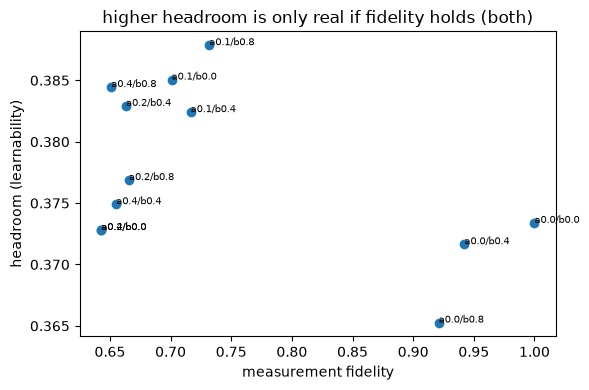

In [25]:
def _meas_route(r):
    m = {rt: max(r["l1"][rt], r["l2"][rt]) for rt in ROUTES}
    o = sorted(m.values(), reverse=True)
    return None if o[0] <= TOL or o[0] - o[1] <= TOL else max(m, key=m.get)


def _fidelity(rows, a, b):
    """Share of decidable rows where the combiner label equals the measurement route —
    the guard against 'higher headroom just means easier-to-imitate labels'."""
    hit = tot = 0
    for r in rows:
        w, mr = combine(r, a, b)[0], _meas_route(r)
        if w is None or mr is None:
            continue
        tot += 1; hit += int(w == mr)
    return hit / tot if tot else float("nan")


# Sweep under BOTH — the production router representation (the one §5 shows carries the signal).
SWEEP_REP = Representation.BOTH
GRID_A = [0.0, 0.1, 0.2, 0.4]
GRID_B = [0.0, 0.4, 0.8]
sweep_rows = []
for a in GRID_A:
    for b in GRID_B:
        proj_ab = with_feats(project_to_router_frame(rows, alpha=a, beta=b))
        if proj_ab.empty:
            continue
        # sweep the TREATMENT (OG decisive + projected), same substrate as §5's "+ all combiner"
        h = evaluate(SWEEP_REP, f"a{a}_b{b}", _add(train_dec, proj_ab))
        sweep_rows.append({"alpha": a, "beta": b, "n_proj": len(proj_ab),
                           "headroom": h["headroom_captured"], "fidelity": _fidelity(rows, a, b)})
sweep = pd.DataFrame(sweep_rows)
sweep.to_parquet(OUT / "alpha_beta_sweep.parquet", index=False)   # sweep grid, persisted
print(f"sweep representation: {SWEEP_REP.value}")
print(sweep.to_string(index=False))
print(f"saved -> {(OUT / 'alpha_beta_sweep.parquet').name}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(sweep["fidelity"], sweep["headroom"])
for _, row in sweep.iterrows():
    ax.annotate(f"a{row.alpha}/b{row.beta}", (row.fidelity, row.headroom), fontsize=7)
ax.set_xlabel("measurement fidelity"); ax.set_ylabel("headroom (learnability)")
ax.set_title(f"higher headroom is only real if fidelity holds ({SWEEP_REP.value})")
plt.tight_layout()
fig.savefig(OUT / "alpha_beta_sweep.png", dpi=120, bbox_inches="tight")   # shareable artifact
plt.show()


## 7. Check 1 — within-population learnability (free)

§5 proved the projected rows don't transfer to decisive truth; it did **not** prove they're junk. The discriminating test is whether they can predict *their own* held-out split: noise is unlearnable even in-population; a coherent-but-conflicting mapping learns itself fine and only fails across the boundary. Train on 80% of the projected rows, score the held-out 20% **against combiner truth**; the OG-decisive router scores the same split as the cross-population reference, and the majority-route constant is the chance floor.

**Read it as:** self-headroom ≈ floor → labels are incoherent — the junk verdict, no eval refinement saves them. Self-headroom well above floor while the OG-trained router lags → the rows encode a real but *different* mapping — an architecture problem (gate / two-head / sample weights), not a label problem.

In [26]:
# §7 — CHECK 1: can the projected rows predict THEMSELVES? Truth here = combiner triples.
from hybrid_search_rrf_dataset.router import SCORE_COLS, StrategyName

REP = Representation.BOTH
ORDER = list(SCORE_COLS)   # fixed route order for argmax -> StrategyName
proj_train = proj.groupby("dataset", group_keys=False).sample(frac=0.8, random_state=0)
proj_test = proj.drop(index=proj_train.index).reset_index(drop=True)
print(f"projected split: train {len(proj_train)} / held-out {len(proj_test)}")

self_router = StrategyRouter(REP, enc).fit(proj_train, all_rows="recommended")
base_router = StrategyRouter(REP, enc).fit(train_dec, all_rows="recommended")   # §5 measurement_only, refit


def _label_route(frame):
    """Argmax route (as .value string) of the stored triple where it separates, else None."""
    win = frame[[SCORE_COLS[s] for s in ORDER]].to_numpy().argmax(axis=1)
    names = pd.Series([ORDER[i].value for i in win], index=frame.index)
    return names.where(_margin(frame) > TOL, None)


def _vs_combiner_truth(router, name):
    routes = router.predict_routes(proj_test)
    six = _six_column(proj_test, routes)
    pred = pd.Series([r.value for r in routes], index=proj_test.index)
    truth = _label_route(proj_test)
    m = truth.notna()
    agree = (pred[m] == truth[m]).mean()
    print(f"{name:>22}: router={six['router']:.3f} oracle={six['oracle']:.3f} "
          f"headroom={six['headroom_captured']:.3f} | argmax-agreement {agree:.1%} (n={int(m.sum())})")
    return pred, truth, m


pred_self, truth, m = _vs_combiner_truth(self_router, "self-trained (80%)")
pred_base, _, _ = _vs_combiner_truth(base_router, "OG-decisive-trained")
maj = truth[m].value_counts(normalize=True)
print(f"{'majority-route floor':>22}: always '{maj.idxmax()}' = {maj.max():.1%}")

print("\nself-trained agreement by trust tier:")
tier = pd.DataFrame({"trust": proj_test["combiner_trust"], "hit": (pred_self == truth).where(m)})
print(tier.dropna().groupby("trust")["hit"].agg(["mean", "count"]).round(3).to_string())

projected split: train 3404 / held-out 851
    self-trained (80%): router=0.719 oracle=0.802 headroom=-0.626 | argmax-agreement 54.2% (n=851)
   OG-decisive-trained: router=0.630 oracle=0.802 headroom=-2.367 | argmax-agreement 31.6% (n=851)
  majority-route floor: always 'dense_only' = 51.5%

self-trained agreement by trust tier:
              mean  count
trust                    
llm_a_only   0.475    592
measurement  0.776    174
r1_assisted  0.529     85


## 8. Check 2 — does a stronger measurement break the ties? (free)

`l2` is gemini retrieval scored against the **same manifest gold** — qrels-grounded and combiner-free. The origin regimes (`all_zero`/`all_tied`/`low_margin`) came from the v2 encoder (`l1`). If a meaningful share of rows turns decisive under `l2`, "non-decisive" was a property of the *measurement*, not the query ("great edge cases, not refined enough") — and the l2-decisive slice doubles as an independent decisive test set for exactly the traffic this architecture targets, fixing the eval-method blind spot directly.

In [27]:
# §8 — CHECK 2: does a stronger measurement break the ties the v2 encoder couldn't?
def _regime(tri):
    v = sorted(tri.values(), reverse=True)
    if v[0] <= TOL:
        return "all_zero"
    if v[0] - v[-1] <= TOL:
        return "all_tied"
    return "low_margin" if v[0] - v[1] < 0.1 else "decisive_strong"


lab = pd.DataFrame({"dataset": [r["dataset"] for r in rows],
                    "query_id": [r["query_id"] for r in rows],
                    "origin": [r["bucket"] for r in rows],
                    "n_judged": [r["n_judged"] for r in rows],
                    "l2_regime": [_regime(r["l2"]) for r in rows]})
lab.to_parquet(OUT / "l2_regimes.parquet", index=False)   # the l2-decisive slice = future test set

meas = lab[lab["n_judged"] > 0]   # no manifest gold -> l2 is all zeros by construction, not evidence
print(f"{len(lab) - len(meas)} rows have no manifest gold (l2 uninformative) — excluded from denominators\n")
print("origin regime (l1/v2 encoder) x regime under l2 (gemini), row-normalized:")
print(pd.crosstab(meas["origin"], meas["l2_regime"], normalize="index").round(3).to_string())

dec_share = meas["l2_regime"].isin(["low_margin", "decisive_strong"]).mean()
strong = (meas["l2_regime"] == "decisive_strong").mean()
print(f"\nl2 separates {dec_share:.1%} of origin-non-decisive rows ({strong:.1%} strongly, margin >= 0.1)")
print(f"-> {int((meas['l2_regime'] == 'decisive_strong').sum())} qrels-grounded, combiner-free decisive rows "
      f"for the population the architecture targets (saved to l2_regimes.parquet)\n")
print("per lane:")
print(pd.crosstab(meas["dataset"], meas["l2_regime"], normalize="index").round(3).to_string())

0 rows have no manifest gold (l2 uninformative) — excluded from denominators

origin regime (l1/v2 encoder) x regime under l2 (gemini), row-normalized:
l2_regime   all_tied  all_zero  decisive_strong  low_margin
origin                                                     
all_tied       0.878     0.000            0.023       0.099
all_zero       0.000     0.464            0.202       0.334
low_margin     0.223     0.021            0.156       0.600

l2 separates 47.3% of origin-non-decisive rows (12.4% strongly, margin >= 0.1)
-> 628 qrels-grounded, combiner-free decisive rows for the population the architecture targets (saved to l2_regimes.parquet)

per lane:
l2_regime       all_tied  all_zero  decisive_strong  low_margin
dataset                                                        
clerc              0.548     0.018            0.082       0.352
crumb-legal-qa     0.210     0.147            0.202       0.441
finder             0.357     0.186            0.089       0.369
quest       

## 9. Check 3 — where does the harm land? (free)

Same two `BOTH`-representation routers as §5, same decisive test — read **per row** instead of as one mean. Two signatures to tell apart:
- **Prior drag**: predictions shift uniformly toward one route everywhere (the tie→rrf hedge is the suspect) → projection artifact, fixable by dropping hedged rows.
- **Boundary interference**: harm concentrates in the 6 cover lanes where the projected rows are dense → the two populations conflict in overlapping feature regions.

Uses §7's `base_router` — run §7 first.

In [28]:
# §9 — CHECK 3: route shifts + per-lane damage on the decisive test (base vs + all combiner).
treat_router = StrategyRouter(REP, enc).fit(_add(train_dec, proj), all_rows="recommended")
t = test.reset_index(drop=True)
rb = pd.Series([r.value for r in base_router.predict_routes(t)], index=t.index)
rt = pd.Series([r.value for r in treat_router.predict_routes(t)], index=t.index)
pick = lambda routes: np.array([t.at[i, f"score_{r}"] for i, r in routes.items()])

d = pd.DataFrame({"dataset": t["dataset"], "base": rb, "treat": rt,
                  "delta": pick(rt) - pick(rb), "truth": _label_route(t)})
mix = pd.DataFrame({"baseline": d["base"].value_counts(normalize=True),
                    "+ all combiner": d["treat"].value_counts(normalize=True),
                    "truth argmax": d["truth"].value_counts(normalize=True)}).round(3)
print("route mix on decisive test:")
print(mix.to_string())

ch = d[d["base"] != d["treat"]]
print(f"\n{len(ch)}/{len(d)} rows change route | mean objective delta on changed rows {ch['delta'].mean():+.4f}")
print(pd.crosstab(ch["base"], ch["treat"]).to_string())

d["in_cover"] = d["dataset"].isin(COVER)
print("\nharm by cover membership (all projected rows live in the 6 cover lanes):")
print(d.groupby("in_cover")["delta"].agg(["mean", "count"]).round(4).to_string())

per = d.groupby("dataset")["delta"].agg(["mean", "count"])
per["n_projected"] = proj["dataset"].value_counts().reindex(per.index).fillna(0).astype(int)
print("\nworst lanes (mean delta, treat - base):")
print(per.sort_values("mean").head(12).round(4).to_string())

route mix on decisive test:
             baseline  + all combiner  truth argmax
dense_only      0.505           0.581         0.519
sparse_only     0.463           0.374         0.431
pure_rrf        0.032           0.044         0.050

229/1376 rows change route | mean objective delta on changed rows -0.1611
treat        dense_only  pure_rrf  sparse_only
base                                          
dense_only            0         9           23
pure_rrf             30         0           11
sparse_only         107        49            0

harm by cover membership (all projected rows live in the 6 cover lanes):
            mean  count
in_cover               
False    -0.0047    650
True     -0.0466    726

worst lanes (mean delta, treat - base):
                                        mean  count  n_projected
dataset                                                         
bright-sustainable-living            -0.4054      2            0
freshstack-langchain                 -0.2549    

## 10. llm_a vs l2 ground truth — the pilot's missing correctness number (free)

The judge pilot certified *stability* (78% order-swap agreement) — it could never certify *correctness*, because the residual had no ground truth by construction. §8 built that ground truth: on l2-decisive_strong rows there is a real, qrels-grounded winner, and every one of them also carries an `llm_route`. This cell scores the judge for the first time.

**Read it as:** accuracy ≈ majority floor → the judge is uninformative on this population; sparse recall far below dense recall → the §9 dense drag is the judge's *systematic bias*, so no prompt iteration fixes it (the failure is the information ceiling — it never sees the corpus). Either way this is the number that decides the judge-everything roadmap.

In [29]:
# §10 — llm_a scored against l2 ground truth (the correctness number the pilot couldn't compute).
L2 = pd.DataFrame([{"dataset": r["dataset"], "query_id": r["query_id"], "origin": r["bucket"],
                    "llm": JUDGE_TO_ROUTE.get(r["llm_route"]),
                    "l2_regime": _regime(r["l2"]),
                    "l2_winner": max(r["l2"], key=r["l2"].get)} for r in rows])
strong = L2[L2["l2_regime"] == "decisive_strong"]
judged = strong[strong["llm"].notna()].copy()   # drops parse failures + rows the judge never saw (no gold)
judged["hit"] = judged["llm"] == judged["l2_winner"]

acc = judged["hit"].mean()
maj = judged["l2_winner"].value_counts(normalize=True)
print(f"llm_a accuracy on l2-decisive_strong truth: {acc:.1%} (n={len(judged)}; "
      f"{len(strong) - len(judged)} strong rows lack an llm route)")
print(f"majority floor: always '{maj.idxmax()}' = {maj.max():.1%}")

print("\nconfusion (rows = l2 winner, cols = llm pick):")
print(pd.crosstab(judged["l2_winner"], judged["llm"]).to_string())

print("\nrecall by true route (dense-bias check — sparse recall << dense recall = systematic bias):")
print(judged.groupby("l2_winner")["hit"].agg(["mean", "count"]).round(3).to_string())

print("\naccuracy by origin regime:")
print(judged.groupby("origin")["hit"].agg(["mean", "count"]).round(3).to_string())

print("\nllm pick mix vs truth mix (bias direction at a glance):")
print(pd.DataFrame({"llm_picks": judged["llm"].value_counts(normalize=True),
                    "l2_truth": maj}).round(3).to_string())

llm_a accuracy on l2-decisive_strong truth: 50.8% (n=628; 0 strong rows lack an llm route)
majority floor: always 'dense_only' = 87.1%

confusion (rows = l2 winner, cols = llm pick):
llm          dense_only  pure_rrf  sparse_only
l2_winner                                     
dense_only          306       193           48
pure_rrf             12         5            1
sparse_only          30        25            8

recall by true route (dense-bias check — sparse recall << dense recall = systematic bias):
              mean  count
l2_winner                
dense_only   0.559    547
pure_rrf     0.278     18
sparse_only  0.127     63

accuracy by origin regime:
             mean  count
origin                  
all_tied    0.250     40
all_zero    0.580    307
low_margin  0.466    281

llm pick mix vs truth mix (bias direction at a glance):
             llm_picks  l2_truth
dense_only       0.554     0.871
pure_rrf         0.355     0.029
sparse_only      0.091     0.100


## 11. Measurement escalation — l2 triples as labels (free, cached)

The replacement hypothesis for the combiner: **escalate ties to a stronger measurement, not to an opinion.** The l2 triples are the same objective, on the same [0,1] scale, against the same manifest gold as `score_*` — they drop straight into the router's schema with no projection, no α/β, no hedge.

Train `decisive + l2-decisive rows` and score on **both truths**: the OG-decisive test (does adding them cost anything on the router's home turf?) and a held-out 20% of the l2-strong rows (the §8 test-set fix — routing quality on the population this architecture was built for, measured for the first time). The baseline's row on `l2_strong_heldout` is itself news: how well OG-decisive training transfers to the tie population.

**Read it as:** gain on `l2_strong_heldout` with no loss on `og_decisive` → GO for scaling l2 across the full residual (~47% of ~82K rows at well under the judge's price). Loss on `og_decisive` → the gemini-measured winner doesn't transfer to the v2 stack — an encoder-transfer scope decision, not a labeling bug. Caveat: the held-out set is only ~125 rows, so read its deltas coarsely.

In [30]:
# §11 — measurement escalation: l2 triples AS labels (no combiner), tested on BOTH truths.
l2f = pd.DataFrame([{"dataset": r["dataset"], "query_id": r["query_id"], "query": r["query"],
                     "shape": "l2_measured", "l2_regime": _regime(r["l2"]),
                     **{f"score_{rt}": float(r["l2"][rt]) for rt in ROUTES}} for r in rows])
l2_strong = with_feats(l2f[l2f["l2_regime"] == "decisive_strong"])
l2_low = with_feats(l2f[l2f["l2_regime"] == "low_margin"])
l2_test = l2_strong.groupby("dataset", group_keys=False).sample(frac=0.2, random_state=0)
l2_train = l2_strong.drop(index=l2_test.index)
l2_test = l2_test.reset_index(drop=True)
print(f"l2 labels: strong {len(l2_strong)} (train {len(l2_train)} / held-out test {len(l2_test)}) "
      f"| low_margin {len(l2_low)}")

assert not (_key(l2_strong) & _key(test)) and not (_key(l2_low) & _key(test)), "l2 rows leaked into OG test"
assert not (_key(l2_train) & _key(l2_test)) and not (_key(l2_low) & _key(l2_test)), "l2 train leaked into l2 test"
print("[leak] clean — l2 train rows disjoint from both test sets on (dataset, query_id)")

subs = [("measurement_only", train_dec),                         # §5 baseline
        ("+ l2 strong", _add(train_dec, l2_train)),              # decisive + l2-strong measurement labels
        ("+ l2 strong+low", _add(train_dec, _add(l2_train, l2_low)))]  # ... + weak-margin l2 rows

out = []
for name, fr in tqdm(subs, desc="l2 escalation"):
    rtr = StrategyRouter(REP, enc).fit(fr, all_rows="recommended")
    for tname, tf in (("og_decisive", test), ("l2_strong_heldout", l2_test)):
        six = _six_column(tf, rtr.predict_routes(tf))
        out.append({"substrate": name, "n_train": len(fr), "test": tname,
                    "router": six["router"], "oracle": six["oracle"],
                    "headroom": six["headroom_captured"]})
r11 = pd.DataFrame(out)
r11.to_parquet(OUT / "l2_escalation_results.parquet", index=False)
for tname in ("og_decisive", "l2_strong_heldout"):
    sub = r11[r11["test"] == tname]
    print(f"\ntest = {tname} ({len(test) if tname == 'og_decisive' else len(l2_test)} rows):")
    print(sub[["substrate", "n_train", "router", "oracle", "headroom"]].round(3).to_string(index=False))
print(f"\nsaved -> {(OUT / 'l2_escalation_results.parquet').name}")

l2 labels: strong 545 (train 437 / held-out test 108) | low_margin 1534
[leak] clean — l2 train rows disjoint from both test sets on (dataset, query_id)


l2 escalation: 100%|██████████| 3/3 [00:00<00:00,  6.20it/s]


test = og_decisive (1376 rows):
       substrate  n_train  router  oracle  headroom
measurement_only     5496   0.726   0.971     0.448
     + l2 strong     5933   0.725   0.971     0.445
 + l2 strong+low     7467   0.720   0.971     0.434

test = l2_strong_heldout (108 rows):
       substrate  n_train  router  oracle  headroom
measurement_only     5496   0.538   0.948    -3.163
     + l2 strong     5933   0.628   0.948    -2.247
 + l2 strong+low     7467   0.655   0.948    -1.976

saved -> l2_escalation_results.parquet


## 12. r1 vs l2 ground truth — closing the opinion tier (free)

§10 scored llm_a; r1 never got its number. Same recipe: r1's route pick (argmax of its triple, on rows where r1 itself separates) against the l2 winner on the decisive_strong rows. r1 shares llm_a's structural limit — a cross-encoder reads query+doc text but never the corpus, and sparse-vs-dense hinges on collection-relative term rarity — so the prediction is the same shape: accuracy under the always-dense floor, weak sparse recall.

**Read it as:** r1 under the floor → the escalation ladder is officially `l1 → l2 → constant`, both opinion instruments retired with numbers attached (and r1 was 73% of the labeling spend). r1 *above* the floor → it earns a second look as a cheap tie-breaker before the constant — but only then.

In [31]:
# §12 — r1 scored against the same l2 ground truth (§10's recipe, reranker edition).
R1 = pd.DataFrame([{"dataset": r["dataset"], "query_id": r["query_id"],
                    "l2_regime": _regime(r["l2"]), "l2_winner": max(r["l2"], key=r["l2"].get),
                    "r1_regime": _regime(r["r1"]), "r1_pick": max(r["r1"], key=r["r1"].get)}
                   for r in rows])
strong12 = R1[R1["l2_regime"] == "decisive_strong"]
dec12 = strong12[~strong12["r1_regime"].isin(["all_zero", "all_tied"])].copy()  # r1 must itself pick a side
dec12["hit"] = dec12["r1_pick"] == dec12["l2_winner"]

maj12 = dec12["l2_winner"].value_counts(normalize=True)
print(f"r1 decidable on {len(dec12)}/{len(strong12)} l2-strong rows "
      f"({len(strong12) - len(dec12)} r1-tied/zero -> no pick)")
print(f"r1 accuracy on l2-decisive_strong truth: {dec12['hit'].mean():.1%} (n={len(dec12)})")
print(f"majority floor on the same rows: always '{maj12.idxmax()}' = {maj12.max():.1%}")

print("\nconfusion (rows = l2 winner, cols = r1 pick):")
print(pd.crosstab(dec12["l2_winner"], dec12["r1_pick"]).to_string())

print("\nrecall by true route (sparse recall << dense recall = same blind spot as llm_a):")
print(dec12.groupby("l2_winner")["hit"].agg(["mean", "count"]).round(3).to_string())

print("\nr1 pick mix vs truth mix:")
print(pd.DataFrame({"r1_picks": dec12["r1_pick"].value_counts(normalize=True),
                    "l2_truth": maj12}).round(3).to_string())

# ladder verdict: every opinion instrument vs the dumbest baseline, same truth (§10's `judged`)
print(f"\nladder verdict on l2-strong truth: llm_a {judged['hit'].mean():.1%} | "
      f"r1 {dec12['hit'].mean():.1%} | always-dense floor {maj.max():.1%}")

r1 decidable on 606/628 l2-strong rows (22 r1-tied/zero -> no pick)
r1 accuracy on l2-decisive_strong truth: 91.7% (n=606)
majority floor on the same rows: always 'dense_only' = 87.1%

confusion (rows = l2 winner, cols = r1 pick):
r1_pick      dense_only  pure_rrf  sparse_only
l2_winner                                     
dense_only          493        26            9
pure_rrf              3        15            0
sparse_only           5         7           48

recall by true route (sparse recall << dense recall = same blind spot as llm_a):
              mean  count
l2_winner                
dense_only   0.934    528
pure_rrf     0.833     18
sparse_only  0.800     60

r1 pick mix vs truth mix:
             r1_picks  l2_truth
dense_only      0.827     0.871
sparse_only     0.094     0.099
pure_rrf        0.079     0.030

ladder verdict on l2-strong truth: llm_a 50.8% | r1 91.7% | always-dense floor 87.1%


## 13. Does r1 generalize toward the zone l2 can't verify? (free)

r1's 91.7% (§12) was measured where l2 truth exists — possibly the easy rows. The unverifiable zone has no truth by definition, so instead of extrapolating the average, extrapolate the **trend**:

- **Probe 1 — margin decay.** Score r1 against ALL decidable l2 rows (strong + low_margin, 2× the §12 population) in bands of shrinking truth margin. Accuracy that holds as margin → tie boundary supports extrapolating into the ties; accuracy collapsing to the in-band floor near zero kills it. (Top-2-tied rows are excluded — their argmax 'winner' is a coin flip, not truth.)
- **Probe 2 — behavior shift.** On the unverifiable zones themselves: does r1 keep deciding at the same rate with a similar pick mix (weak positive — same instrument, same behavior), or abstain en masse / jump to a different route mix (shared limits or degradation)?

Neither probe manufactures truth — they bound how far the §12 number can honestly be stretched. Remember the two-animals split when reading probe 2: generalization into `all_zero` is meaningful measurement (r1's union contains gold); a pick on `all_tied` redefines the objective below qrels depth — a SPEC decision, not a measurement.

probe 1 — r1 accuracy by l2 truth margin (holds toward the left edge = extrapolation defensible):
                 acc  floor    n
band                            
(1e-09, 0.02]  0.652  0.661  115
(0.02, 0.05]   0.796  0.780  436
(0.05, 0.1]    0.751  0.817  257
(0.1, 0.2]     0.829  0.971   35
(0.4, 1.01]    0.923  0.865  571


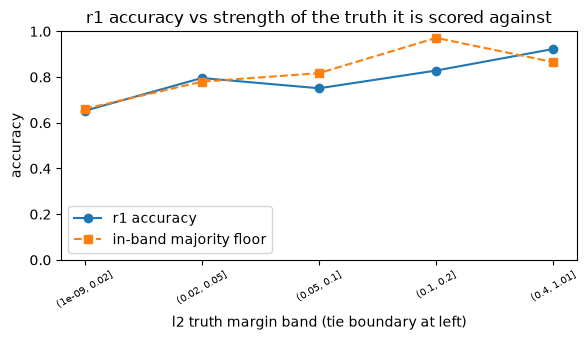


probe 2 — r1 behavior by l2 zone (mass abstention or a pick-mix jump in the last two rows = degradation):
        l2_zone    n  r1_decides  pick_dense_only  pick_sparse_only  pick_pure_rrf
decisive_strong  628       0.965            0.827             0.094          0.079
     low_margin 1758       0.968            0.701             0.187          0.112
       all_tied 1917       0.038            0.548             0.260          0.192
       all_zero  742       0.697            0.623             0.201          0.176


In [32]:
# §13 — does r1's 91.7% extend toward the zone l2 can't verify? Two probes, no truth invented.
def _top2_margin(tri):
    v = sorted(tri.values(), reverse=True)
    return v[0] - v[1]


P = pd.DataFrame([{"dataset": r["dataset"],
                   "l2_regime": _regime(r["l2"]), "l2_winner": max(r["l2"], key=r["l2"].get),
                   "l2_margin": _top2_margin(r["l2"]),
                   "r1_regime": _regime(r["r1"]), "r1_pick": max(r["r1"], key=r["r1"].get)}
                  for r in rows])
P["r1_decides"] = ~P["r1_regime"].isin(["all_zero", "all_tied"])

# Probe 1 — margin-decay: r1 accuracy vs l2 truth margin, sliding toward the tie boundary.
# top-2-tied rows (margin <= TOL) are excluded: their 'winner' is an argmax coin flip, not truth.
ver = P[P["l2_regime"].isin(["decisive_strong", "low_margin"])
        & P["r1_decides"] & (P["l2_margin"] > TOL)].copy()
ver["hit"] = ver["r1_pick"] == ver["l2_winner"]
ver["band"] = pd.cut(ver["l2_margin"], bins=[TOL, 0.02, 0.05, 0.1, 0.2, 0.4, 1.01])
decay = ver.groupby("band", observed=True).agg(
    acc=("hit", "mean"),
    floor=("l2_winner", lambda w: w.value_counts(normalize=True).max()),
    n=("hit", "size"))
print("probe 1 — r1 accuracy by l2 truth margin (holds toward the left edge = extrapolation defensible):")
print(decay.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 3.5))
x = range(len(decay))
ax.plot(x, decay["acc"], marker="o", label="r1 accuracy")
ax.plot(x, decay["floor"], marker="s", linestyle="--", label="in-band majority floor")
ax.set_xticks(list(x)); ax.set_xticklabels([str(b) for b in decay.index], rotation=30, fontsize=7)
ax.set_xlabel("l2 truth margin band (tie boundary at left)"); ax.set_ylabel("accuracy"); ax.set_ylim(0, 1)
ax.legend(); ax.set_title("r1 accuracy vs strength of the truth it is scored against")
plt.tight_layout(); plt.show()

# Probe 2 — behavior shift: decidability + pick mix across zones, verifiable -> unverifiable.
recs = []
for z in ("decisive_strong", "low_margin", "all_tied", "all_zero"):
    m = P[P["l2_regime"] == z]
    picks = m.loc[m["r1_decides"], "r1_pick"].value_counts(normalize=True)
    recs.append({"l2_zone": z, "n": len(m), "r1_decides": m["r1_decides"].mean(),
                 **{f"pick_{rt}": picks.get(rt, 0.0) for rt in ROUTES}})
print("\nprobe 2 — r1 behavior by l2 zone (mass abstention or a pick-mix jump in the last two rows = degradation):")
print(pd.DataFrame(recs).round(3).to_string(index=False))

## 14. Conclusion — what this notebook settled

**The question** ("do combiner-labelled non-decisive rows lift the router?") is answered **no**, and the post-mortem
settled far more than the question asked.

**Verdicts, with provenance:**

| # | Finding | Evidence |
|---|---------|----------|
| 1 | Combiner labels HURT decisive routing, dose-dependently | §5: 0.448 → 0.440 (+grounded) → 0.388 (+all); no α/β rescues it (§6, whole grid ≤ 0.388) |
| 2 | The harm is the llm_a opinion tier: unlearnable AND dense-biased | §7: llm tier 47.5% self-consistency vs 51.5% floor; §9: 107/229 test flips are sparse→dense, 10× concentrated in cover lanes |
| 3 | llm_a is DEAD as a route labeler — information ceiling, not prompt | §10: 50.8% accuracy vs 87.1% always-dense floor; sparse recall 12.7%; it never sees the corpus, and sparse wins live in collection-relative rarity |
| 4 | ~Half the residual was a measurement artifact, not junk queries | §8: l2 (stronger dense leg) makes 47.3% decidable; winner mix 87% dense (instrument-relative). all_tied is the exception: 88% survive = the qrels-depth wall |
| 5 | Measurement labels transfer; but the residual barely wants a router | §11: +l2-strong costs nothing on OG (0.445 vs 0.448) and lifts l2-heldout 0.538→0.655 — yet const-dense sits at ~0.85 there, and the residual's headroom pool is ~0.10/row vs 0.44 on decisive rows |
| 6 | r1 is accurate only where truth is easy; it cannot break ties | §12: 91.7% vs 87.1% floor — but §13: the edge exists only at l2-margin>0.4; at the tie boundary acc=floor (0.652 vs 0.661); on all_tied it abstains 96% |

**The l2 resolution ledger — exact counts on the 5,045 labelled rows (finding 4, un-normalized):**

| origin (v2 verdict) | drawn | → l2 strong | → l2 low-margin | resolved at all | stayed stuck |
|---|---|---|---|---|---|
| all_zero | 1,520 | **307** | 508 | **815** (54%) | 705 still zero |
| all_tied | 1,725 | **40** | 170 | **210** (12%) | 1,515 still tied |
| low_margin | 1,800 | **281** (low → high upgrade) | 1,080 stay low | — | **402 collapse to tied**, 37 to zero |

The 628 strong rows decompose as 307 (ex-zero) + 40 (ex-tied) + 281 (upgraded low-margin) — only **347 came from
genuinely undecided rows**. And l2 doesn't just refine weak verdicts, it *overturns* them: 402 + 37 low_margin rows
(~24% of that band) lose their v2 margin entirely under l2 — margins < 0.1 are measurement noise in both directions,
which is why §11's "+strong+low" substrate diluted where "+strong" didn't.

**Volume extrapolation to the full v2-100K target (projection, NOT measured — rate × population per origin):**
the target's non-decisive mass is 81,526 rows (33,304 low_margin / 24,751 all_tied / 23,471 all_zero vs 9,567
decisive_strong). At §8's per-origin rates, scaling l2 across it would yield ~10.5K new strong rows (strong tier
9,567 → ~20.1K, +110%) and ~40.8K decidable total (labelable coverage 10.5% → ~55%), for ~$130–200 of indexing.
all_tied contributes almost nothing (~3K of 24.8K) — the qrels wall holds at scale. Caveats: rates come from 6
English cover lanes with real per-lane spread, and the 87%-dense winner skew travels with these labels (only the
dense leg was upgraded).

**The mechanism behind 3 and 6:** r1 and llm_a are *refinement operators* — functions of the routes' own outputs
(or less). They can sharpen signal retrieval already produced, never create signal where retrieval is undecided.
l2 worked because it is a *generation operator*: it changed what got retrieved. The a-priori filter for any future
instrument: **does it observe anything the existing signals don't?**

**The ladder that survives: `l1 → l2 → constant/hedge`.**
- l2-decidable residual (~47%): label by measurement; r1's one surviving role is concordance QA on high-margin l2 labels.
- all_tied: genuinely indifferent at current qrels depth — serve the hedge, never train, never label. Every instrument
  failed at this wall identically; only deeper qrels move it, and finding 5 caps what that purchase is worth.
- all_zero-under-l2: a retrieval-headroom problem (encoder/corpus), not a routing problem.
- Router investment returns to the decisive population: BOTH ≈ EMBEDDING (§5 — the 81 engineered features add ~nothing
  over e5), so the uncaptured 55% of decisive headroom points at collection-relative rarity features.

**Closed:** the judge-everything roadmap ($5–15K) — see §10. **Left open (SPEC-level, deliberately not decided here):**
(a) may the route label ever be defined below current qrels depth (the all_tied wall)? (b) is l2-scaling across the full
residual (~$130–200) funded as *dataset supply*, now that its router-training rationale is gone?

**Method lesson** (why per-instrument pilots saw none of this): no independent referee existed until §8 built one;
pilots validate on the easy checkable stratum but instruments deploy on the hard one; the harms were compositional
(visible only via label → train → predict → independent truth); and llm_a/r1/features share a blind spot, so they
cross-confirm. Checklist for next time: referee first, hardest checkable stratum, one end-to-end dose-response,
and the refinement-vs-generation question before any spend.

Total spend for all of the above: ~$21 (gemini indexing + labeling), against the $5–15K plan it replaced.

---

**Post-conclusion update — §15 depth probe ran (09-01):** first-relevant-rank@500 on the 742 l2-all_zero rows:
**614 rescued (83%)**, bands ≤10: 6 (consistency noise, 0.8%) / 11–50: **295 (window artifacts — already fetched at
labeling, discarded by the objective's top-10 window)** / 51–100: 88 / 101–500: 225 / absent@500: **128**. Dense finds
gold for 78% at median rank 63 vs sparse 57% at median 124; winners 441 dense / 155 sparse / 8 rrf / 10 tie, of which
215 are "clear" (best rank ≤ half the runner-up). The all_zero account closes: of the original 1,520 drawn zeros,
815 resolved by l2 + 614 rank-graded + **only 128 truly absent (~8%)** — "unretrievable" was mostly a weak dense leg
plus a blind objective window. Scaled to v2-100K: ~23.5K zeros ≈ ~12.6K l2-decidable + ~9K rank-graded + ~1.9K headroom
class. Caveats travel: ranks are gemini-stack, gold-at-rank-63 still scores 0 on the objective (rank-graded labels are
"fails least", pending the same SPEC decision as tie depth), and recording `first_relevant_rank` during normal labeling
would make ~40% of this probe unnecessary at scale. The 128 absentees are the L1 relevance-judge queue (~$1 at luna
prices). **Whether these preferences actually improve the router is §16.**

---

**FINAL VERDICT — §17–§20, the model-class and attribution arc (09-01, 5 seeds, placebo-controlled):**

- **Model class is real on decisive rows:** every EncoderRouter (MLP) baseline (0.460–0.506 headroom across draws;
  5-seed mean 0.492 ± 0.016) beats every linear StrategyRouter fit (0.434–0.450). §16's "information ceiling" held for
  the residual but the linear head WAS leaving decisive headroom on the table.
- **Single-fit noise floor ≈ ±0.02–0.03 headroom** (identical substrate drew 0.473 and 0.506). Every §17/§19 delta
  under that floor was re-measured over 5 seeds in §20 (`seed_sweep.parquet`).
- **l2 labels: the one label program with router content.** l2-heldout +0.079 (~2.7se) AND a 6× seed-variance collapse
  (sd 0.064 → 0.011) at no og cost — measurement labels from a stronger encoder both lift and *stabilize*.
- **rank labels: measurement without router content.** Alone: indistinguishable from their mass placebo and from
  baseline on both tests (content +0.004 ± 0.004 og, −0.035 ± 0.038 l2h). §17's +0.028/+0.119 were seed draws. They
  remain valid depth measurements and dataset supply. (Possible +0.053 l2×rank interaction at ~3se — unproven under
  ~16 comparisons; the only loose thread.)
- **llm labels: dead under every framing.** Content −0.005 ± 0.004 (og) / −0.043 ± 0.035 (l2h); const-dense placebo
  beats its real labels (0.750 vs 0.707); og dilution ~3se. Combined with §10 (50.8% vs 87.1% floor), the opinion tier
  is closed under both model classes, with confidence intervals.
- **r1 labels: real content, wrong slot — the census's only REAL content verdicts.** vs its mass placebo: +0.027 ±
  0.004 on og (~7se — §12's accuracy is genuinely trainable, query-paired signal) yet **net −0.024 vs baseline** (~3se
  dilution); on l2-heldout its content is REAL-NEGATIVE (−0.048 ± 0.019) — its non-dense calls are net wrong against an
  87%-dense truth. Informative-but-harmful-as-targets + serve-unavailable = the textbook LUPI profile: r1 belongs in a
  privileged branch (encoder_router), not in the labels. Follow-up: §21 branches-on, then §22 r1 privileged branch.
- **Mass beats content on the residual:** the best residual-adjacent treatment measured is labeling every unmeasurable
  row "dense" — placebo r1-const 0.796 ± 0.035, placebo const-dense 0.750 ± 0.075 — content-free labels top the whole
  census. The residual stays unroutable (five confirmations, §16–§20); serving = gate + constant. On home turf NOTHING
  beats pure decisive measurement (0.492): every augmentation in ten substrates is neutral-to-negative net.
- Follow-up program for the remainder: `docs/research/relevance-judge-recovery.md` (atomic relevance judging,
  validation-gated, pre-registered as dataset supply — NOT router improvement).

## 15. Depth probe — first-relevant-rank@500 on the unresolved all_zero rows

The 742 rows even l2 called all_zero: is the gold truly unreachable, or just below the objective's window? Re-query the
same gemini collections at `fetch_limit=500` per route and record where the first manifest-gold doc actually sits.
**PAID but tiny** (gemini query embeds only, ~2/row — cents total; the collections already exist), `RUN_LIVE`-gated,
cached to `depth_probe.parquet`.

Reading the bands of the best rank across routes:
- **≤10** — should be ~empty; anything here contradicts the stored l2 score (consistency check on retrieval variance).
- **11–50** — *window artifact*: this doc was already fetched during labeling; the objective (Hit@1 + NDCG@10) just can't see past rank 10.
- **51–500** — true depth rescue: only visible because we fetched deeper.
- **absent@500** — the genuine retrieval-headroom class at this stack.

For rescued rows, the route with the lower first-relevant rank is a *measurement-grounded* preference (`clear` = best rank
≤ half the runner-up). This is the free instrument that decides how much of all_zero still needs the relevance judge.

In [38]:
# §15 — depth probe: PAID (query embeds only, ~cents), gated. Rate-limit aware:
# resumes from checkpoint, throttled workers, exponential backoff on 429 (inference-service limit).
RUN_LIVE = True
K = 500
WORKERS = 2                # 4 workers x ~2 server-side gemini embeds/row tripped the inference 429
DEPTH_PATH = OUT / "depth_probe.parquet"

zero_rows = [r for r in rows if _regime(r["l2"]) == "all_zero"]
_done = pd.read_parquet(DEPTH_PATH) if DEPTH_PATH.exists() else pd.DataFrame(columns=["dataset", "query_id"])
_done_keys = set(zip(_done["dataset"].astype(str), _done["query_id"].astype(str)))
todo15 = [r for r in zero_rows if (str(r["dataset"]), str(r["query_id"])) not in _done_keys]
print(f"target: {len(zero_rows)} l2-all_zero rows | done {len(_done)} | todo {len(todo15)}")

if not todo15:
    depth = _done
    print(f"complete: {len(depth)} rows in {DEPTH_PATH.name} (delete to re-probe)")
elif not RUN_LIVE:
    depth = _done if len(_done) else None
    print("RUN_LIVE is False — flip to probe the remaining rows (resumes, never re-pays).")
else:
    import requests
    from concurrent.futures import ThreadPoolExecutor, as_completed
    from qdrant_client.http.exceptions import ResponseHandlingException
    TRANSIENT = (ResponseHandlingException, requests.exceptions.RequestException)

    def _retryable(exc):
        m = str(exc).lower()
        return isinstance(exc, TRANSIENT) or "429" in m or "rate limit" in m or "too many requests" in m

    _man = pd.read_parquet(DATA_DIR / "rungs" / "100k-v2" / "candidate_manifests.parquet").astype(
        {"query_id": str, "doc_id": str})
    GOLD = {k: set(g["doc_id"]) for k, g in _man[_man["relevance"] >= 1].groupby(["dataset", "query_id"])}
    deep = {}
    for lane in sorted({r["dataset"] for r in todo15}):
        deep[lane] = {rt: cls(client, pilot.collection(lane), gemini_dense_cfg(), SPARSE_CFG, fetch_limit=K)
                      for rt, cls in (("dense_only", DenseOnlyStrategy),
                                      ("sparse_only", SparseOnlyStrategy),
                                      ("pure_rrf", PureRRFStrategy))}

    def probe(r):
        judged = GOLD.get((r["dataset"], str(r["query_id"])), set())
        rec = {"dataset": r["dataset"], "query_id": str(r["query_id"]), "origin": r["bucket"]}
        for attempt in range(6):
            try:
                for rt in ROUTES:
                    ranking = deep[r["dataset"]][rt].rank(str(r["query"]))
                    rec[f"rank_{rt}"] = next((i + 1 for i, d in enumerate(ranking) if str(d) in judged), None)
                return rec
            except Exception as exc:
                if attempt == 5 or not _retryable(exc):
                    raise
                time.sleep(min(60, 4 * 2 ** attempt))   # 4s, 8s, 16s, 32s, 60s

    recs, errs = _done.to_dict("records"), 0
    prog = tqdm(total=len(todo15), desc="depth@500")
    with ThreadPoolExecutor(max_workers=WORKERS) as tpool:
        futs = {tpool.submit(probe, r): r["query_id"] for r in todo15}
        for fut in as_completed(futs):
            try:
                recs.append(fut.result())
            except Exception as exc:
                errs += 1
                tqdm.write(f"[{futs[fut]}] FAILED: {type(exc).__name__}: {str(exc)[:120]}")
            prog.update(1)
            if len(recs) % 25 == 0:
                pd.DataFrame(recs).to_parquet(DEPTH_PATH, index=False)
    depth = pd.DataFrame(recs)
    depth.to_parquet(DEPTH_PATH, index=False)
    print(f"probed {len(depth)}/{len(zero_rows)} rows ({errs} errors this pass) -> {DEPTH_PATH.name}")

target: 742 l2-all_zero rows | done 125 | todo 617


depth@500: 100%|██████████| 617/617 [37:53<00:00,  1.70s/it]  

probed 742/742 rows (0 errors this pass) -> depth_probe.parquet


In [39]:
# §15 analysis — where was the gold hiding, and who wins at depth?
assert depth is not None and len(depth), "run the probe first (RUN_LIVE above)"
RCOLS = [f"rank_{rt}" for rt in ROUTES]
best = depth[RCOLS].min(axis=1)


def band(rk):
    if pd.isna(rk):
        return "absent@500"
    if rk <= 10:
        return "<=10 (!consistency)"
    if rk <= 50:
        return "11-50 (window artifact)"
    return "51-100" if rk <= 100 else "101-500"


depth["band"] = [band(b) for b in best]
order_bands = ["<=10 (!consistency)", "11-50 (window artifact)", "51-100", "101-500", "absent@500"]
print("best first-relevant rank across routes:")
print(depth["band"].value_counts().reindex(order_bands).fillna(0).astype(int).to_string())

found = depth[best.notna()].copy()
print(f"\nrescued at depth: {len(found)}/{len(depth)} ({len(found)/len(depth):.0%})")
for rt in ROUTES:
    f = depth[f"rank_{rt}"]
    print(f"  {rt:>12}: found {f.notna().mean():.0%}" + (f", median rank {f.median():.0f}" if f.notna().any() else ""))

arr = found[RCOLS].to_numpy(dtype=float)
srt15 = np.sort(np.where(np.isnan(arr), np.inf, arr), axis=1)
b, s = srt15[:, 0], srt15[:, 1]
found["winner"] = np.where(b == s, "tie", np.array(ROUTES)[np.nanargmin(np.where(np.isnan(arr), np.inf, arr), axis=1)])
found["clear"] = (b * 2 <= s) & (found["winner"] != "tie")   # runner-up absent -> s=inf -> clear
print("\nwinner by first-relevant rank (rescued rows):")
print(found.groupby("winner").agg(n=("clear", "size"), clear=("clear", "sum")).to_string())
print("\nby lane:")
print(pd.crosstab(found["dataset"], found["winner"], margins=True).to_string())

best first-relevant rank across routes:
band
<=10 (!consistency)          6
11-50 (window artifact)    295
51-100                      88
101-500                    225
absent@500                 128

rescued at depth: 614/742 (83%)
    dense_only: found 78%, median rank 63
   sparse_only: found 57%, median rank 124
      pure_rrf: found 71%, median rank 66

winner by first-relevant rank (rescued rows):
               n  clear
winner                 
dense_only   441    174
pure_rrf       8      0
sparse_only  155     41
tie           10      0

by lane:
winner          dense_only  pure_rrf  sparse_only  tie  All
dataset                                                    
clerc                    3         1            6    1   11
crumb-legal-qa          58         1           24    3   86
finder                 121         1           24    2  148
quest                   94         2           40    2  138
rarb-math                9         0            0    1   10
scirgen-geo-en     

## 16. The convincing test — do rank-graded preferences improve the router? (free)

The §15 rescues become labels: score triple = **reciprocal rank of first gold** per route (rank 63 → 0.016, absent → 0).
Scale doesn't matter — under `all_rows="recommended"` the router consumes *winners*, not magnitudes. Two treatment
variants: every rescued row, and the 2×-margin `clear` subset only.

Three truths, same shape as §11: `og_decisive` (home turf — no-harm check), `l2_strong_heldout` (§11's test — carryover),
and **`rank_heldout`** — a held-out 20% of the rescued rows scored against their own rank truth: can the router learn
"fails least" on the population these labels were built for?

**Read it as:** treatment ≫ baseline on `rank_heldout` with og flat → the labels are learnable and safe — adopt with a
`depth_rank` provenance tier. Treatment ≈ baseline there, or headroom stays deep below the best constant → §11's lesson
repeats (this population wants a constant), and the labels' value is dataset supply, not router lift. n(rank_heldout)
is only ~120 — read deltas coarsely. Requires §11 (`l2_test`) and §15 (`depth`) to have run.

In [40]:
# §16 — rank-graded labels into the router: 3 substrates x 3 truths (free, offline).
assert depth is not None and len(depth), "run §15 first"
qtext16 = {(str(r["dataset"]), str(r["query_id"])): str(r["query"]) for r in rows}

rr16 = depth.copy()
for rt in ROUTES:
    rr16[f"score_{rt}"] = (1.0 / rr16[f"rank_{rt}"]).fillna(0.0)   # reciprocal rank; absent -> 0
rr16 = rr16[rr16[[f"score_{rt}" for rt in ROUTES]].max(axis=1) > 0].copy()   # rescued rows only
rr16["query"] = [qtext16[(str(d), str(q))] for d, q in zip(rr16["dataset"], rr16["query_id"])]
rr16["shape"] = "depth_rank"
arr16 = rr16[[f"rank_{rt}" for rt in ROUTES]].to_numpy(dtype=float)
srt16 = np.sort(np.where(np.isnan(arr16), np.inf, arr16), axis=1)
rr16["clear"] = srt16[:, 0] * 2 <= srt16[:, 1]

rankf = with_feats(rr16)
rank_test = rankf.groupby("dataset", group_keys=False).sample(frac=0.2, random_state=0)
rank_train = rankf.drop(index=rank_test.index)
rank_test = rank_test.reset_index(drop=True)
print(f"rank-graded labels: {len(rankf)} covered (of {len(rr16)} rescued) | "
      f"train {len(rank_train)} (clear {int(rank_train['clear'].sum())}) / heldout {len(rank_test)}")

assert not (_key(rankf) & _key(test)), "rank rows leaked into OG test"
assert not (_key(rankf) & _key(l2_test)), "rank rows leaked into l2 test"
assert not (_key(rank_train) & _key(rank_test)), "rank train leaked into rank test"
print("[leak] clean on all three test sets")

subs16 = [("measurement_only", train_dec),
          ("+ rank all", _add(train_dec, rank_train)),
          ("+ rank clear", _add(train_dec, rank_train[rank_train["clear"]]))]
tests16 = [("og_decisive", test), ("l2_strong_heldout", l2_test), ("rank_heldout", rank_test)]

out16 = []
for name, fr in tqdm(subs16, desc="rank labels"):
    rtr = StrategyRouter(REP, enc).fit(fr, all_rows="recommended")
    for tname, tf in tests16:
        six = _six_column(tf, rtr.predict_routes(tf))
        out16.append({"substrate": name, "n_train": len(fr), "test": tname,
                      "router": six["router"], "oracle": six["oracle"],
                      "headroom": six["headroom_captured"]})
r16 = pd.DataFrame(out16)
r16.to_parquet(OUT / "rank_label_results.parquet", index=False)
for tname, tf in tests16:
    sub = r16[r16["test"] == tname]
    print(f"\ntest = {tname} ({len(tf)} rows):")
    print(sub[["substrate", "n_train", "router", "oracle", "headroom"]].round(3).to_string(index=False))
print(f"\nsaved -> {(OUT / 'rank_label_results.parquet').name}")

rank-graded labels: 548 covered (of 614 rescued) | train 438 (clear 158) / heldout 110
[leak] clean on all three test sets


rank labels: 100%|██████████| 3/3 [00:00<00:00,  3.41it/s]


test = og_decisive (1376 rows):
       substrate  n_train  router  oracle  headroom
measurement_only     5496   0.726   0.971     0.448
      + rank all     5934   0.725   0.971     0.445
    + rank clear     5654   0.724   0.971     0.444

test = l2_strong_heldout (108 rows):
       substrate  n_train  router  oracle  headroom
measurement_only     5496   0.538   0.948    -3.163
      + rank all     5934   0.532   0.948    -3.218
    + rank clear     5654   0.550   0.948    -3.037

test = rank_heldout (110 rows):
       substrate  n_train  router  oracle  headroom
measurement_only     5496   0.017   0.031    -2.412
      + rank all     5934   0.018   0.031    -2.059
    + rank clear     5654   0.018   0.031    -2.164

saved -> rank_label_results.parquet


## 17. Head swap — is it a model ceiling? EncoderRouter on §16's exact frames (free)

The §16 verdict has an untested objection: the linear `StrategyRouter` may simply lack capacity for a non-linear
dense/sparse boundary. The repo's own candidate answers it: **`EncoderRouter`** — MLP encoder (→256→128 latent),
non-linear route layers, **acceptability heads** (`ok_dense`, `ok_sparse`; NaN-masked, RRF = hedge rule, never a
prediction) — the first head-to-head between the two routers (never run before: decisive-only substrates were judged
too small to bother with).

Held fixed vs §16: the three substrates, the three truths. Changed: the head, and its native inputs — e5
(`QueryEmbeddings`, cached), char-ngram SVD (lexical channel, fit on train only), `ZipfStats` (background term
rarity), plus the engineered features (z-scored on train). Privileged branches stay OFF — one variable at a time;
if the plain MLP moves, a branch pass comes next. Targets use the package's acceptability rule (`score ≥ oracle −
0.3`, all-zero masked); rank rows (RR scale, where 0.3 would mark everything ok) use the 2×-rank rule, which is the
same formula with tolerance `0.5·oracle`.

`rank_train_fitcheck` is the bias/variance separator: **can't fit its own training rows** → the signal isn't in the
inputs at all — information ceiling, capacity objection closed. **Fits train, fails `rank_heldout`** → memorizable
noise, not structure. **Fits train AND lifts `rank_heldout` toward the ~0.027 constant** → model ceiling was real,
the router head gets redesigned. Pre-registered trap: a lift driven by e5-locality may be per-lane constants in
disguise — still a gate+constant win, not a routing one.

In [41]:
# §17 — EncoderRouter (MLP, acceptability heads) vs the linear control (§16's cached numbers).
from sklearn.preprocessing import StandardScaler
from encoder_router.model import EncoderRouter
from encoder_router.table import HEAD_ROUTES, NgramSvd, ZipfStats
from encoder_router.training import QueryEmbeddings

E5_17 = QueryEmbeddings("intfloat/multilingual-e5-small")
zipf17 = ZipfStats()
SCORE_ALL = [f"score_{r}" for r in ROUTES]


def ok_targets(fr):
    """Package acceptability rule; depth_rank rows get tolerance 0.5*oracle (== rank <= 2x best)."""
    heads = fr[[f"score_{r}" for r in HEAD_ROUTES]].to_numpy(float)
    oracle = fr[SCORE_ALL].to_numpy(float).max(axis=1)
    tol = np.where(fr["shape"].to_numpy() == "depth_rank", 0.5 * oracle, 0.3)
    ok = (heads >= (oracle - tol)[:, None]).astype(float)
    ok[oracle <= TOL] = np.nan
    return ok


def x17(fr, svd, scaler):
    e = E5_17.matrix(fr)
    n = svd.transform(fr["query"])
    z = zipf17.frame(fr["query"]).to_numpy()
    f = scaler.transform(fr[feat_cols].fillna(0.0).to_numpy(float))
    return np.hstack([e, n, z, f]).astype(np.float32)


tests17 = tests16 + [("rank_train_fitcheck", rank_train.reset_index(drop=True))]
out17 = []
for name, fr in subs16:                                   # §16's exact substrates
    tr = fr.reset_index(drop=True)
    svd = NgramSvd().fit(tr["query"])                      # fold-local lexical basis
    scaler = StandardScaler().fit(tr[feat_cols].fillna(0.0).to_numpy(float))
    X, Y = x17(tr, svd, scaler), ok_targets(tr)
    val = np.zeros(len(tr), dtype=bool)
    val[np.random.RandomState(0).choice(len(tr), max(1, len(tr) // 10), replace=False)] = True
    er = EncoderRouter(seed=0).fit(X[~val], Y[~val], None, None, None,
                                   x_val=X[val], val_route_targets=Y[val])
    for tname, tf in tests17:
        tfr = tf.reset_index(drop=True)
        routes17 = [StrategyName(r) for r in er.predict_routes(x17(tfr, svd, scaler))]
        six = _six_column(tfr, routes17)
        out17.append({"substrate": name, "test": tname, "router": six["router"],
                      "oracle": six["oracle"], "headroom": six["headroom_captured"]})
    print(f"[{name}] fitted ({len(er.history)} epochs)")

r17 = pd.DataFrame(out17)
r17.to_parquet(OUT / "encoder_router_results.parquet", index=False)
for tname, tf in tests17:
    sub = r17[r17["test"] == tname]
    print(f"\ntest = {tname} ({len(tf)} rows) — compare §16's linear table:")
    print(sub[["substrate", "router", "oracle", "headroom"]].round(3).to_string(index=False))
print(f"\nsaved -> {(OUT / 'encoder_router_results.parquet').name}")

embedding 2427 queries with intfloat/multilingual-e5-small


Batches: 100%|██████████| 10/10 [00:04<00:00,  2.09it/s]


embedding 600 queries with intfloat/multilingual-e5-small


Batches: 100%|██████████| 3/3 [00:01<00:00,  1.89it/s]


embedding 75 queries with intfloat/multilingual-e5-small


...

embedding 342 queries with intfloat/multilingual-e5-small


Batches: 100%|██████████| 2/2 [00:00<00:00,  3.07it/s]


[measurement_only] fitted (35 epochs)


[+ rank all] fitted (36 epochs)


[+ rank clear] fitted (34 epochs)

test = og_decisive (1376 rows) — compare §16's linear table:
       substrate  router  oracle  headroom
measurement_only   0.737   0.971     0.473
      + rank all   0.749   0.971     0.501
    + rank clear   0.737   0.971     0.474

test = l2_strong_heldout (108 rows) — compare §16's linear table:
       substrate  router  oracle  headroom
measurement_only   0.495   0.948    -3.601
      + rank all   0.614   0.948    -2.387
    + rank clear   0.567   0.948    -2.864

test = rank_heldout (110 rows) — compare §16's linear table:
       substrate  router  oracle  headroom
measurement_only   0.015   0.031    -2.793
      + rank all   0.017   0.031    -2.252
    + rank clear   0.016   0.031    -2.446

test = rank_train_fitcheck (438 rows) — compare §16's linear table:
       substrate  router  oracle  headroom
measurement_only   0.013   0.033    -4.494
      + rank all   0.024   0.033    -1.438
    + rank clear   0.017   0.033    -3.400

saved -> encoder_

## 18. The combiner labels under the vindicated reader — llm_a's last door (free)

§16→§17 proved a label verdict can be reader-conditional: rank labels were inert under the linear head and worth
+0.028/+0.119 under the MLP. §5's "combiner labels hurt" was measured under the linear head only — so it gets the
same retest, with the llm tier **isolated** so llm_a's contribution is read directly, not through the mix.

What canNOT change here: §10's accuracy verdict (llm_a 50.8% vs the 87.1% always-dense floor) is reader-independent —
the opinions are wrong regardless of the consumer. What CAN change: whether the projected rows as *training mass*
(their grounded component especially) help the MLP the way rank rows did. Same §17 pipeline: acceptability targets,
e5 + ngram-SVD + Zipf + features, branches off, same three truths.

**Pre-registered predictions:** `+ grounded` may help (it is mostly measurement in combiner clothing);
`+ all combiner` ≤ `+ grounded` (the llm tier dilutes); `+ llm tier only` ≤ baseline — if THAT line comes back
positive instead, llm_a earns a reprieve and §10's harm mechanism needs rethinking. Whatever lands, this closes the
opinion-tier question under both model classes, and the notebook's llm_a verdict becomes final.

In [42]:
# §18 — §5's substrates under the EncoderRouter reader; llm tier isolated. Same §17 machinery.
llm_tier = proj[proj["combiner_trust"] == "llm_a_only"]
subs18 = [
    ("measurement_only", train_dec),                    # control, same pipeline for a clean seed-for-seed table
    ("+ grounded", _add(train_dec, grounded)),          # measurement/r1-trust projected rows (§5's mild tier)
    ("+ llm tier only", _add(train_dec, llm_tier)),     # llm_a's isolated contribution — the kill-or-reprieve line
    ("+ all combiner", _add(train_dec, proj)),          # §5's harmful substrate
]
print("substrates:", {n: len(f) for n, f in subs18})

out18 = []
for name, fr in subs18:
    tr = fr.reset_index(drop=True)
    svd = NgramSvd().fit(tr["query"])
    scaler = StandardScaler().fit(tr[feat_cols].fillna(0.0).to_numpy(float))
    X, Y = x17(tr, svd, scaler), ok_targets(tr)
    val = np.zeros(len(tr), dtype=bool)
    val[np.random.RandomState(0).choice(len(tr), max(1, len(tr) // 10), replace=False)] = True
    er = EncoderRouter(seed=0).fit(X[~val], Y[~val], None, None, None,
                                   x_val=X[val], val_route_targets=Y[val])
    for tname, tf in tests16:
        tfr = tf.reset_index(drop=True)
        routes18 = [StrategyName(r) for r in er.predict_routes(x17(tfr, svd, scaler))]
        six = _six_column(tfr, routes18)
        out18.append({"substrate": name, "n_train": len(tr), "test": tname,
                      "router": six["router"], "oracle": six["oracle"],
                      "headroom": six["headroom_captured"]})
    print(f"[{name}] fitted ({len(er.history)} epochs)")

r18 = pd.DataFrame(out18)
r18.to_parquet(OUT / "combiner_mlp_results.parquet", index=False)
for tname, tf in tests16:
    sub = r18[r18["test"] == tname]
    print(f"\ntest = {tname} ({len(tf)} rows) — §5 linear verdicts: 0.448 -> grounded 0.440 -> all 0.388:")
    print(sub[["substrate", "n_train", "router", "oracle", "headroom"]].round(3).to_string(index=False))
print(f"\nsaved -> {(OUT / 'combiner_mlp_results.parquet').name}")

substrates: {'measurement_only': 5496, '+ grounded': 6828, '+ llm tier only': 8419, '+ all combiner': 9751}


[measurement_only] fitted (35 epochs)
embedding 682 queries with intfloat/multilingual-e5-small


Batches: 100%|██████████| 3/3 [00:02<00:00,  1.12it/s]


[+ grounded] fitted (66 epochs)
embedding 1704 queries with intfloat/multilingual-e5-small


Batches: 100%|██████████| 7/7 [00:03<00:00,  1.96it/s]


[+ llm tier only] fitted (29 epochs)


[+ all combiner] fitted (32 epochs)

test = og_decisive (1376 rows) — §5 linear verdicts: 0.448 -> grounded 0.440 -> all 0.388:
       substrate  n_train  router  oracle  headroom
measurement_only     5496   0.737   0.971     0.473
      + grounded     6828   0.733   0.971     0.463
 + llm tier only     8419   0.737   0.971     0.473
  + all combiner     9751   0.731   0.971     0.458

test = l2_strong_heldout (108 rows) — §5 linear verdicts: 0.448 -> grounded 0.440 -> all 0.388:
       substrate  n_train  router  oracle  headroom
measurement_only     5496   0.495   0.948    -3.601
      + grounded     6828   0.659   0.948    -1.934
 + llm tier only     8419   0.668   0.948    -1.846
  + all combiner     9751   0.743   0.948    -1.084

test = rank_heldout (110 rows) — §5 linear verdicts: 0.448 -> grounded 0.440 -> all 0.388:
       substrate  n_train  router  oracle  headroom
measurement_only     5496   0.015   0.031    -2.793
      + grounded     6828   0.016   0.031    -2.592
 + llm 

## 19. The full escalation ladder — disjoint provenance, llm_a on the true remainder, placebo-controlled (free)

Every row labelled by the best instrument that reaches it, each exactly once: OG decisive → measurement; l2-decidable →
l2 triples (§11); depth-rescued zeros → rank rule (§16); and the **remainder nothing can measure** (l2 all_tied +
absent@500) → llm_a's own picks, one-hot on the acceptability heads (dense/sparse → that head; rrf → both 0, the hedge;
parse-failure → masked). l2 low-margin rows stay out (§11 showed they dilute). This is the escalation architecture as
originally designed, with llm_a in its intended last-stand role.

Two **placebo arms** replace the remainder's labels while keeping its rows: `const-dense` (majority prior — tests
whether the gain is just dense-leaning mass from these lanes) and `shuffled` (real labels, permuted — tests whether the
per-query pairing matters). **`real − placebo` = llm_a's actual content.** Rungs are cumulative, so each table row's
delta over the previous rung is that instrument's marginal value under the MLP.

**Read it as:** llm rung ≈ both placebos → llm_a contributes mass, not content — final kill, in its own designed role.
llm rung > both placebos by a real margin → the reprieve is genuine and the ladder ships with all four rungs.

In [43]:
# §19 — cumulative ladder + placebo arms. Reuses §17's pipeline (x17, ok_targets, E5_17).
COLS19 = ["dataset", "query_id", "query"] + feat_cols
RNG19 = np.random.RandomState(0)

# remainder = drawn rows no measurement recovers: l2 all_tied + depth-absent all_zero
absent = depth[depth[[f"rank_{rt}" for rt in ROUTES]].isna().all(axis=1)]
rem_keys = ({(str(d), str(q)) for d, q in zip(absent["dataset"], absent["query_id"])}
            | {(str(r["dataset"]), str(r["query_id"])) for r in rows if _regime(r["l2"]) == "all_tied"})
rem_src = [r for r in rows if (str(r["dataset"]), str(r["query_id"])) in rem_keys]
rem = with_feats(pd.DataFrame([{"dataset": r["dataset"], "query_id": str(r["query_id"]),
                                "query": str(r["query"]), "llm_route": r["llm_route"]} for r in rem_src]))
print(f"remainder (all_tied + absent@500): {len(rem_src)} rows -> {len(rem)} covered")

def llm_onehot(fr):
    """llm pick -> acceptability heads: dense/sparse -> that head 1, other 0; rrf -> both 0 (hedge); else masked."""
    y = np.full((len(fr), len(HEAD_ROUTES)), np.nan)
    for i, lr in enumerate(fr["llm_route"]):
        rt = JUDGE_TO_ROUTE.get(lr)
        if rt in HEAD_ROUTES:
            y[i] = 0.0; y[i, HEAD_ROUTES.index(rt)] = 1.0
        elif lr == "rrf":
            y[i] = 0.0
    return y

Y_real = llm_onehot(rem)
Y_const = np.zeros_like(Y_real); Y_const[:, HEAD_ROUTES.index("dense_only")] = 1.0
Y_shuf = Y_real[RNG19.permutation(len(Y_real))]
print(f"llm labels on remainder: {int(np.isnan(Y_real).all(axis=1).sum())} masked (no/failed pick)")

base = [(train_dec, ok_targets(train_dec))]
l2r  = [(l2_train, ok_targets(l2_train))]
rkr  = [(rank_train, ok_targets(rank_train))]
ladder = [
    ("measurement_only",        base),
    ("+ l2",                    base + l2r),
    ("+ l2 + rank",             base + l2r + rkr),
    ("+ l2 + rank + llm(rem)",  base + l2r + rkr + [(rem, Y_real)]),
    ("placebo: const-dense",    base + l2r + rkr + [(rem, Y_const)]),
    ("placebo: shuffled",       base + l2r + rkr + [(rem, Y_shuf)]),
]

out19 = []
for name, parts in ladder:
    tr = pd.concat([f[COLS19] for f, _ in parts], ignore_index=True)
    Y = np.vstack([y for _, y in parts])
    svd = NgramSvd().fit(tr["query"])
    scaler = StandardScaler().fit(tr[feat_cols].fillna(0.0).to_numpy(float))
    X = x17(tr, svd, scaler)
    val = np.zeros(len(tr), dtype=bool)
    val[RNG19.choice(len(tr), max(1, len(tr) // 10), replace=False)] = True
    er = EncoderRouter(seed=0).fit(X[~val], Y[~val], None, None, None,
                                   x_val=X[val], val_route_targets=Y[val])
    for tname, tf in tests16:
        tfr = tf.reset_index(drop=True)
        routes19 = [StrategyName(r) for r in er.predict_routes(x17(tfr, svd, scaler))]
        six = _six_column(tfr, routes19)
        out19.append({"substrate": name, "n_train": len(tr), "test": tname,
                      "router": six["router"], "oracle": six["oracle"],
                      "headroom": six["headroom_captured"]})
    print(f"[{name}] fitted ({len(er.history)} epochs, n={len(tr)})")

r19 = pd.DataFrame(out19)
r19.to_parquet(OUT / "ladder_results.parquet", index=False)
for tname, tf in tests16:
    sub = r19[r19["test"] == tname]
    print(f"\ntest = {tname} ({len(tf)} rows):")
    print(sub[["substrate", "n_train", "router", "oracle", "headroom"]].round(3).to_string(index=False))
print(f"\nsaved -> {(OUT / 'ladder_results.parquet').name}")
print("\nattribution: llm content on each test = row['+ l2 + rank + llm(rem)'] - max(placebo rows)")

remainder (all_tied + absent@500): 2045 rows -> 1628 covered
llm labels on remainder: 0 masked (no/failed pick)


[measurement_only] fitted (39 epochs, n=5496)


[+ l2] fitted (33 epochs, n=5933)


[+ l2 + rank] fitted (34 epochs, n=6371)


[+ l2 + rank + llm(rem)] fitted (52 epochs, n=7999)


[placebo: const-dense] fitted (38 epochs, n=7999)


[placebo: shuffled] fitted (38 epochs, n=7999)

test = og_decisive (1376 rows):
             substrate  n_train  router  oracle  headroom
      measurement_only     5496   0.752   0.971     0.506
                  + l2     5933   0.745   0.971     0.491
           + l2 + rank     6371   0.740   0.971     0.478
+ l2 + rank + llm(rem)     7999   0.735   0.971     0.468
  placebo: const-dense     7999   0.720   0.971     0.434
     placebo: shuffled     7999   0.731   0.971     0.459

test = l2_strong_heldout (108 rows):
             substrate  n_train  router  oracle  headroom
      measurement_only     5496   0.576   0.948    -2.778
                  + l2     5933   0.650   0.948    -2.023
           + l2 + rank     6371   0.652   0.948    -2.006
+ l2 + rank + llm(rem)     7999   0.742   0.948    -1.097
  placebo: const-dense     7999   0.684   0.948    -1.678
     placebo: shuffled     7999   0.706   0.948    -1.456

test = rank_heldout (110 rows):
             substrate  n_train  rout

## 20. Seed sweep — error bars for every sub-noise delta (free, ~30–60 min, resumable)

§19 exposed a ±0.03 single-fit noise floor (identical baseline: 0.473 in §17/§18, 0.506 in §19 — the val split moved
it). Every open question is a delta *inside* that band, so: ten substrates × 5 seeds (~50 fits; `+ r1` / `placebo: r1-const` give r1's route triples — the real objective under R1-augmented relevance, §12-validated at 92% on high margins — their first seat in any MLP experiment, placebo-controlled like the rest) (torch init, val
split, SVD, and the shuffled placebo's permutation all vary per seed), on the two informative truths. rank_heldout is
dropped — flat across all six §19 substrates, question closed.

Settles, with mean ± sd: (1) **did rank-graded labels ever improve this router** — `+ rank` vs `placebo: rank-const`
(same rows as majority-dense mass) attributes §17's +0.028/+0.119 to content or ballast, and `+ l2` / `+ rank` /
`+ l2 + rank` decompose the marginals §19 conflated; (2) is llm_a's +0.036 content-over-placebo real — the final
line of the opinion chapter. Read
the llm attribution as `mean(real) − mean(best placebo)` against its combined se: > 2×se → the provenance tier is
earned; within it → llm_a closes with confidence intervals instead of assertions.

Incremental: persists per fit to `seed_sweep.parquet` and skips completed (substrate, seed) pairs on re-run.

In [46]:
# §20 — 5 substrates x 5 seeds, incremental + resumable. Reuses §19's parts (base/l2r/rkr/rem/Y_*).
SEEDS20 = range(5)
SWEEP_PATH = OUT / "seed_sweep.parquet"
NAMES20 = ["measurement_only", "+ l2", "+ rank", "placebo: rank-const",
           "+ r1", "placebo: r1-const",
           "+ l2 + rank", "+ l2 + rank + llm(rem)",
           "placebo: const-dense", "placebo: shuffled"]

# r1's own route triples (REAL objective scale under R1-augmented relevance) as labels,
# on the rows where r1 actually decides — its first seat in any MLP experiment.
_r1dec = [r for r in rows if _regime(r["r1"]) not in ("all_zero", "all_tied")]
r1f = with_feats(pd.DataFrame([{"dataset": r["dataset"], "query_id": str(r["query_id"]),
                                "query": str(r["query"]), "shape": "r1_scored",
                                **{f"score_{rt}": float(r["r1"][rt]) for rt in ROUTES}}
                               for r in _r1dec]))
Y_r1c = np.zeros((len(r1f), len(HEAD_ROUTES))); Y_r1c[:, HEAD_ROUTES.index("dense_only")] = 1.0
print(f"r1-decidable: {len(_r1dec)} rows -> {len(r1f)} covered")
tests20 = [("og_decisive", test), ("l2_strong_heldout", l2_test)]


def parts20(name, seed):
    if name == "placebo: shuffled":   # the shuffle is part of the treatment -> redraw it per seed
        ys = Y_real[np.random.RandomState(2000 + seed).permutation(len(Y_real))]
        return base + l2r + rkr + [(rem, ys)]
    if name == "placebo: rank-const":  # rank ROWS, majority labels — is §17's rank gain just mass?
        yc = np.zeros((len(rank_train), len(HEAD_ROUTES))); yc[:, HEAD_ROUTES.index("dense_only")] = 1.0
        return base + [(rank_train, yc)]
    return {"measurement_only": base,
            "+ l2": base + l2r,
            "+ rank": base + rkr,
            "+ r1": base + [(r1f, ok_targets(r1f))],
            "placebo: r1-const": base + [(r1f, Y_r1c)],
            "+ l2 + rank": base + l2r + rkr,
            "+ l2 + rank + llm(rem)": base + l2r + rkr + [(rem, Y_real)],
            "placebo: const-dense": base + l2r + rkr + [(rem, Y_const)]}[name]


done20 = pd.read_parquet(SWEEP_PATH) if SWEEP_PATH.exists() else pd.DataFrame(
    columns=["substrate", "seed", "test", "router", "headroom"])
have20 = set(zip(done20["substrate"], done20["seed"], done20["test"]))
recs20 = done20.to_dict("records")
jobs20 = [(n, s) for n in NAMES20 for s in SEEDS20
          if not all((n, s, t) in have20 for t, _ in tests20)]
print(f"{len(jobs20)} fits to run ({len(NAMES20) * len(SEEDS20) - len(jobs20)} cached)")

for n, s in tqdm(jobs20, desc="seed sweep"):
    parts = parts20(n, s)
    tr = pd.concat([f[COLS19] for f, _ in parts], ignore_index=True)
    Y = np.vstack([y for _, y in parts])
    svd = NgramSvd(seed=s).fit(tr["query"])
    scaler = StandardScaler().fit(tr[feat_cols].fillna(0.0).to_numpy(float))
    X = x17(tr, svd, scaler)
    val = np.zeros(len(tr), dtype=bool)
    val[np.random.RandomState(1000 + s).choice(len(tr), max(1, len(tr) // 10), replace=False)] = True
    er = EncoderRouter(seed=s).fit(X[~val], Y[~val], None, None, None,
                                   x_val=X[val], val_route_targets=Y[val])
    for tname, tf in tests20:
        if (n, s, tname) in have20:
            continue
        tfr = tf.reset_index(drop=True)
        routes20 = [StrategyName(r) for r in er.predict_routes(x17(tfr, svd, scaler))]
        six = _six_column(tfr, routes20)
        recs20.append({"substrate": n, "seed": s, "test": tname,
                       "router": six["router"], "headroom": six["headroom_captured"]})
    pd.DataFrame(recs20).to_parquet(SWEEP_PATH, index=False)   # per-fit checkpoint

sw = pd.DataFrame(recs20)
for tname, tf in tests20:
    sub = (sw[sw["test"] == tname].groupby("substrate")
           .agg(router_mean=("router", "mean"), router_sd=("router", "std"),
                head_mean=("headroom", "mean"), head_sd=("headroom", "std"), n=("seed", "count"))
           .reindex(NAMES20))
    print(f"\ntest = {tname} ({len(tf)} rows), over {len(list(SEEDS20))} seeds:")
    print(sub.round(3).to_string())

# r1 attribution: r1's real route triples vs the same rows as majority-dense mass
for tname, _ in tests20:
    t = sw[sw["test"] == tname]
    rr, rc = t[t["substrate"] == "+ r1"]["router"], t[t["substrate"] == "placebo: r1-const"]["router"]
    if len(rr) and len(rc):
        diff = rr.mean() - rc.mean()
        se = float(np.sqrt(rr.var(ddof=1) / len(rr) + rc.var(ddof=1) / len(rc)))
        print(f"[{tname}] r1 content = {diff:+.4f} +/- {se:.4f} (se) "
              f"-> {'REAL (>2se)' if abs(diff) > 2 * se else 'within noise'}")

# rank attribution: real rank labels vs the same rows as majority mass (both over baseline)
for tname, _ in tests20:
    t = sw[sw["test"] == tname]
    rk, rc = t[t["substrate"] == "+ rank"]["router"], t[t["substrate"] == "placebo: rank-const"]["router"]
    diff = rk.mean() - rc.mean()
    se = float(np.sqrt(rk.var(ddof=1) / len(rk) + rc.var(ddof=1) / len(rc)))
    print(f"[{tname}] rank content = {diff:+.4f} +/- {se:.4f} (se) "
          f"-> {'REAL (>2se)' if abs(diff) > 2 * se else 'within noise'}")

# the llm attribution, with error bars
for tname, _ in tests20:
    t = sw[sw["test"] == tname]
    real = t[t["substrate"] == "+ l2 + rank + llm(rem)"]["router"]
    best_plc = max((t[t["substrate"] == p]["router"] for p in
                    ("placebo: const-dense", "placebo: shuffled")), key=lambda x: x.mean())
    diff = real.mean() - best_plc.mean()
    se = float(np.sqrt(real.var(ddof=1) / len(real) + best_plc.var(ddof=1) / len(best_plc)))
    print(f"\n[{tname}] llm content = {diff:+.4f} +/- {se:.4f} (se) "
          f"-> {'REAL (>2se)' if abs(diff) > 2 * se else 'within noise'}")

r1-decidable: 2897 rows -> 2537 covered
10 fits to run (40 cached)












































































































































































































































































































































































































































































seed sweep: 100%|██████████| 10/10 [00:47<00:00,  4.78s/it]


test = og_decisive (1376 rows), over 5 seeds:
                        router_mean  router_sd  head_mean  head_sd  n
substrate                                                            
measurement_only              0.746      0.007      0.492    0.016  5
+ l2                          0.741      0.006      0.481    0.014  5
+ rank                        0.739      0.006      0.478    0.015  5
placebo: rank-const           0.736      0.007      0.470    0.016  5
+ r1                          0.735      0.004      0.468    0.009  5
placebo: r1-const             0.708      0.007      0.407    0.015  5
+ l2 + rank                   0.740      0.001      0.480    0.003  5
+ l2 + rank + llm(rem)        0.731      0.008      0.460    0.017  5
placebo: const-dense          0.712      0.016      0.416    0.036  5
placebo: shuffled             0.737      0.006      0.472    0.014  5

test = l2_strong_heldout (108 rows), over 5 seeds:
                        router_mean  router_sd  head_mean  he